# plotting full ensemble

In [1]:
#import datetime as dt
import cftime 
from datetime import datetime as py_datetime

import time
import datetime
from datetime import datetime as py_datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import sys
sys.path.append('src/')
sys.path.append('src/fsrc/')
import ens

from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap, to_rgb

# from contextlib import redirect_stdout
# import io
def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

## settings for plots - makes them look nicer
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('xtick', labelsize=13) 
plt.rc('ytick', labelsize=13) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})

In [2]:
import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime as dt
from subprocess import *
#from cbook2 import *
import src.plot_src.ctables as ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap


import sys
sys.path.append('fsrc/')
from fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state



#from ens import read_CM1_ens

def subplot_format(n):
    ''' keeps an approximately square subplot organization. 
    The longer number will always be columns (so the figure will be wider than tall). 
    Reverse row,col in the return if you would prefer a taller plot'''
    
    facs= list( set(x for tup in ([i, n//i] for i in range(1, int(n**0.5)+1) if n % i == 0) for x in tup))
    if len(facs) %2 == 0:
        row, col = facs[int(len(facs)/2)-1:int(len(facs)/2)+1]
    else:
        col = row = int(np.sqrt(n))
    return row, col

def silence_print(func, *args, **kwargs):
    with redirect_stdout(io.StringIO()) as f: # this just silences all the obnoxious output
        return func(*args, **kwargs)


In [24]:
PRIOR =False
fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/'
name = os.path.basename(os.path.normpath(fpath))
#myDTstring = '2024,05,08,20,05,00'

time = dt.datetime(2024,5,8,21,40)

with open(f'{fpath}{name}.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=PRIOR)

# print(files[0])
ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 21:40:00

 ==> FindRestartFile:  Found time 7800 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/member001/cm1rst_000026.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 21:40:00 


 Wallclock time for serial read netCDF ensemble files: 44.337  sec

 Wallclock time to convert from C to A grid: 0.663  sec

 Wallclock time to create ensemble means: 1.235  sec

 Wallclock time to read arrays from netCDF ensemble files: 46.974  sec

 Wallclock time to create coordinates: 0.0  sec


           2           2
60 72


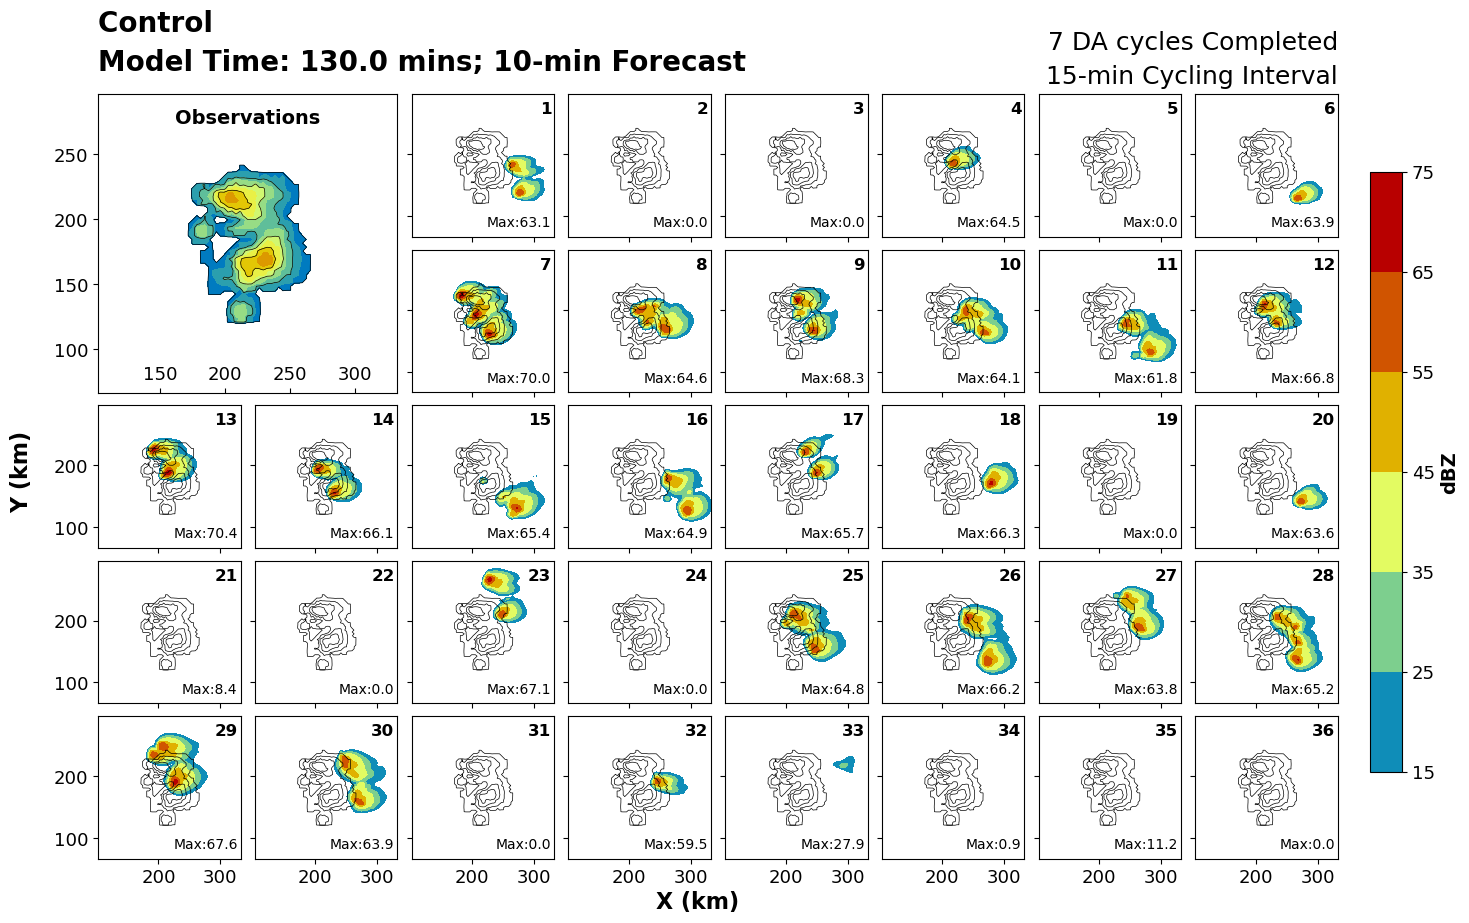

In [25]:

ne = ens_state.ne
height = 2 # in km
cref = True
include_obs = True
plot_width = 230#280#220 # in km 
smooth_obs = False

fig, axes = plt.subplots(5,8, sharex=True, sharey=True, figsize=(16,10), subplot_kw={'aspect':'equal'})
gs = axes[0,1].get_gridspec()
for ax in [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]:
    ax.remove()

axbig = fig.add_subplot(gs[0:2, 0:2])
axbig.set_aspect('equal')
axbig.tick_params(axis="x", direction="in", pad=-20)

ax_list = []# axes.flatten
for n,ax in enumerate(axes.flatten()):
    if n not in [0,1,8,9]:
        ax_list.append(ax)


x = ens_state.xc[:]/1000
y = ens_state.yc[:]/1000
z = ens_state.zc[:]/1000

zi = findnearest(z, height) # if cref is chosen, this isn't used
# prepping the observations
if include_obs == True:
    obs_3d = ens.ens_GRID_RELECTIVITY(ens_state, cref=cref) 
    if cref == True: obs = obs_3d[0]
    else: obs = obs_3d[zi] # this data is interpolated to the model grid, so this is okay to index with zi
    if smooth_obs: obs = gaussian_filter(obs, sigma=.5)

    smth = gaussian_filter(obs, sigma=12)
    yc, xc = np.where(smth == smth.max())

    yy,xx = np.where(obs>5)
    xc = np.min(xx)+int((np.max(xx) - np.min(xx))/2)
    yc = np.min(yy)+int((np.max(yy) - np.min(yy))/2)

else:
    # full_field = ens_state['DBZ'][:].sum(axis=(0,1))
    # smth = gaussian_filter(ens_state['DBZ'][-1,:].max(axis=1), sigma=12)
    # yc, xc = np.where(full_field == full_field.max())

    yy,xx = np.where(ens_state['DBZ'][-1].max(axis=0)>5)
    xc = np.min(xx)+int((np.max(xx) - np.min(xx))/2)
    yc = np.min(yy)+int((np.max(yy) - np.min(yy))/2)



print(yc, xc)

if plot_width!= None:
    axes[-1,-1].set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) # shift plot 20 km to the right, it just looks better
    axes[-1,-1].set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)
    axbig.set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) 
    axbig.set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)


### obs
if include_obs:
    axbig.contourf(x,y, obs, cmap=ctables.REF_default, levels=np.arange(15,80,5))
    axbig.contour(x,y, obs, colors='k', linewidths=0.5, levels=np.arange(15,80,10))
    axbig.text(0.5, .95, 'Observations', ha='center', va='top', fontsize=14, weight='bold', transform=axbig.transAxes)
else:
    if cref == True: mean_field = ens_state['DBZ'][-1,:].max(axis=0) 
    else: mean_field = ens_state['DBZ'][-1,zi] 
    
    axbig.contourf(x,y, mean_field, cmap=ctables.REF_default, levels=np.arange(15,80,5))
    axbig.contour(x,y, mean_field, colors='k', linewidths=0.5, levels=np.arange(15,80,10))
    axbig.text(0.5, .95, 'Ensemble Mean', ha='center', va='top', fontsize=14, weight='bold', transform=axbig.transAxes)


for i,ax in enumerate(ax_list):
    if cref == True: dbz = ens_state['DBZ'][i,:].max(axis=0) 
    else: dbz = ens_state['DBZ'][i,zi] 
    
    im=ax.contourf(x,y, dbz, cmap=ctables.REF_default, levels=np.arange(15,80,10)) 
    #ax.contourf(x,y, dbz, colors=['C0'], levels=[5,100]) 

    if include_obs:
        ax.contour(x,y, obs, colors='k', levels=np.arange(15,80,10), linewidths=0.5)
    ax.text(0.98, .05, f'Max:{dbz.max():.1f}', va='bottom',ha='right', fontsize=10, transform=ax.transAxes)
    ax.text(0.98, .95, f'{i+1}', ha='right', va='top',fontsize=12, transform=ax.transAxes, weight='bold')

plt.subplots_adjust(hspace = .05 ,wspace = .1)

cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('dBZ', weight='bold')


fig.text(0.5, 0.07, 'X (km)', ha='center', va='center', weight='bold', fontsize=16);
fig.text(0.07,0.5, r'Y (km)', weight='bold', va='center', fontsize=16, rotation='vertical');

freq = ens_state['experiment']['DA_PARAMS']['assim_freq']
da_start = dt.datetime.strptime(ens_state['experiment']['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
da_end = dt.datetime.strptime(ens_state['experiment']['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')
curr_time = ens_state['datetime'][0]

text='(Posteriors)'
if PRIOR:text = '(Priors)'
    
if curr_time > da_end:
    ncycles = 1 + int((da_end - da_start).seconds/freq)
    forecast_len = int((curr_time - da_end).seconds/60)
    text_add = (f'; {forecast_len}-min Forecast')
    text=''
else:
    ncycles = 1 + int(np.floor((curr_time - da_start).seconds/freq))
    text_add = ''

    if PRIOR: ncycles -=1
    
start = dt.datetime.strptime(ens_state['experiment']['date_time'], '%Y-%m-%d %H:%M:%S')

model_time = (curr_time - start).seconds/60
title = f'{name} {text}\nModel Time: {model_time} mins{text_add}'
axbig.set_title(title, fontsize=20, x=0, ha='left', weight='bold', y=1.05, linespacing=1.5);

title2 = f'{ncycles} DA cycles Completed\n{int(freq/60)}-min Cycling Interval'
axes[0,7].set_title(title2, linespacing=1.5, ha='right', x=1, y=1.02);

# Creating Ensemble mean files for forecast (put in base dir)

In [129]:
name = 'CI_15min'

for name in ['CI_10min', 'CI_5min']:
    print(name)

    fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{name}/'
    with open(f'{fpath}{name}.exp', 'rb') as f:
        exper = json.load(f)
    
    start_time = dt.datetime(2024,5,8,21,35)
    end_time = dt.datetime(2024,5,8,22,30)
    timedel = dt.timedelta(minutes=5)
    timearr = np.arange(start_time, end_time+timedel, timedel)
    
    
    for i, time in enumerate(timearr):
        time = time.astype(dt.datetime)
    
        files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=False)
        ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
        ens.ens_CM1_coords(ens_state)
    
        if i == 0:
            allvars = ens_state['state_vector']['xyz3d']
    
            nt,nk,nj,ni,ne = len(timearr), ens_state['nz'],ens_state['ny'],ens_state['nx'],ens_state['ne']+1
            
            coords = {'t'    : np.arange(0, nt),'ni'   : np.arange(0, ni),'nj'   : np.arange(0, nj),'nk'   : np.arange(0, nk), 'ne':np.arange(0,ne)}
            data_vars = { 'time': (['t'], [t.astype(dt.datetime) for t in timearr]), 
                          'xh': (['ni'], ens_state['xc'][:]/1000), 
                          'yh': (['nj'], ens_state['yc'][:]/1000),
                          'z' : (['nk'], ens_state['zc'][:]/1000)}
            
            for v in allvars:
                data_vars[v.lower()] = (['t','ne','nk','nj','ni'], np.zeros([nt,ne,nk,nj,ni])*np.nan)
            myds = xr.Dataset(data_vars, coords)
    
        for v in allvars:
            myds[v.lower()][i,:,:,:,:] = ens_state[v][:]
    
        del ens_state
    myds.to_netcdf(exper['base_path']+'/full_ens_fcst.nc', format='NETCDF4')

CI_10min

 ==> FindRestartFiles: Date and time supplied is 2024_05_08 21:35:00

 ==> FindRestartFile:  Found time 7500 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min/member001/cm1rst_000025.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 21:35:00 


 Wallclock time for serial read netCDF ensemble files: 8.254  sec

 Wallclock time to convert from C to A grid: 0.577  sec

 Wallclock time to create ensemble means: 1.25  sec

 Wallclock time to read arrays from netCDF ensemble files: 10.819  sec

 Wallclock time to create coordinates: 0.0  sec

 ==> FindRestartFiles: Date and time supplied is 2024_05_08 21:40:00

 ==> FindRestartFile:  Found time 7800 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min/member001/cm1rst_000026.nc

 ==> READ_CM1_

In [49]:
#===============================================================================
from ens import mymap
import scipy
import pandas as pd
import colormaps as cmaps

def get_dbz_fast(analysis_time, fpath, cref=True, ob_file=None):

    if fpath[-1]=='/': fpath=fpath[:-1]
    name = os.path.basename(fpath)
    
    with open(f'{fpath}/{name}.exp', 'rb') as f: exper = json.load(f)
    
    # These values are set in the experiment dictionary created at the begining of the run
    
    xoffset = exper['xoffset']
    yoffset = exper['yoffset']
    glat    = exper['lat0']
    glon    = exper['lon0']
      
    if ob_file == None:
      ob_file = exper['radar_obs']
    
    ob_f = pd.read_csv(ob_file)
    
    # look for reflectivity +/- 2.5 min 
    
    dt            = datetime.timedelta(0,30)
    begin  = cftime.date2num(analysis_time - dt, "seconds since 1970-01-01 00:00:00")
    ending = cftime.date2num(analysis_time + dt, "seconds since 1970-01-01 00:00:00")
    
    data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) &(ob_f.kind==12) # only dbz
    
    odata = ob_f[data_mask]
    
    data    = odata['value'][:]
    lats    = odata['lat'][:]
    lons    = odata['lon'][:]
    hgts    = odata['height'][:]
    
    cm1 = exper['cm1namelist']
    names = [c[1] for c in cm1]
    nx=cm1[np.where(np.array(names)=='nx')[0][0]][2]
    ny=cm1[np.where(np.array(names)=='ny')[0][0]][2]
    nz=cm1[np.where(np.array(names)=='nz')[0][0]][2]
    dx=cm1[np.where(np.array(names)=='dx')[0][0]][2]
    
    fstate_xc = np.arange(0, nx*dx, dx) + dx/2
    fstate_xc += exper['xoffset']
    fstate_yc = np.arange(0, ny*dx, dx) + dx/2
    fstate_yc += exper['yoffset']
    
    temp = xr.open_dataset(sorted(glob.glob(f"{exper['fcst_members'][0]}/*.nc"))[0], decode_timedelta=True)
    fstate_zc=temp.zh.values
    temp.close()
    
    map      = mymap(fstate_xc, fstate_yc, glat, glon)
    xob, yob = map(lons, lats)
    xob, yob = xob+xoffset, yob+yoffset
    
    # The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
    #     ens stores the x/y grid in grid-internal coordinates
    # Create obs list for KDTree query...
    xyz_obs  = np.vstack((hgts,yob,xob))
    obs_list = list(xyz_obs.transpose())
    
    # Create 3D grid arrays for KDTree
    y_array, z_array, x_array = np.meshgrid(fstate_yc, fstate_zc, fstate_xc)
    xyz_grid = np.dstack([z_array.ravel(),y_array.ravel(),x_array.ravel()])[0]
      
    # Use cKDTree to create fast indexing for 3D grid....
    
    mytree = scipy.spatial.cKDTree(xyz_grid)
    distance, indices1D = mytree.query(obs_list)
    
    # these are the integer indices that you now pass into the fortran routine. They
    # are the un-raveled 3D index locations nearest the observation point in the 3D array
    
    kk,jj,ii = np.unravel_index(indices1D, (len(fstate.zc), len(fstate.yc), len(fstate.xc))) 
    dbz3d = obs_2_grid3d(data, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)

    # Create composite reflectivity, and then replicate it into a 3D array
    
    dbz2d = np.zeros((1,))
    
    if cref:
    
        dbz2d = dbz3d.max(axis=0)
    
        for k in np.arange(nz):
            dbz3d[k] = dbz2d
      
    #if verbose: print("\n ==> ens_GRID_REFL: 2D composite DBZ requested   Max:  %4.1f   Min:  %4.1f" % (dbz2d.max(), dbz2d.min()))
    
    del xyz_obs, x_array, y_array, z_array, xyz_grid, mytree
             
    return dbz3d


def get_mean_var(files, var, height=None, return_dims=False, return_all_dims=False):
    myvar = []
    for f in files:
        cm1 = xr.open_dataset(f, decode_timedelta=True)
        if height != None:
            zi = findnearest(cm1.zh, height)
            myvar.append(cm1[var][0,zi].values)
        else:
            myvar.append(cm1[var][0].values)
    if return_dims:
        z,y,x = cm1.zh.values, cm1.yh.values, cm1.xh.values
        
    cm1.close()
    meanvar = np.mean(myvar, axis=0)
    
    if return_dims:
        if (height==None) | (return_all_dims==True):
            return z,y,x, meanvar
        else:
            return y,x, meanvar
    else:
        return meanvar


/tmp/ipykernel_2098537/4164774522.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test/member001/cm1rst_{t:06d}.nc')


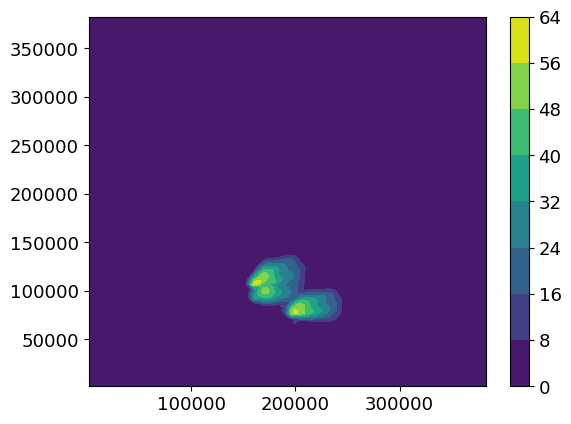

In [4]:
t=9
cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test/member001/cm1rst_{t:06d}.nc')

plt.contourf(cm1.xh, cm1.yh, cm1.dbz[0,:].max(axis=0))
plt.colorbar()

In [12]:
#fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test/member001/"

prs, tarr = [],[]
prsum = []
for t in np.arange(0, 7, 1):
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test/member001/cm1rst_{t:06d}.nc')
    tc = cm1.time/1e9/60
    tarr.append(tc)
    prs.append(np.mean(cm1.wa[0,findnearest(cm1.zf, 5000)]))
   # prsum.append(np.sum(cm1.prs[0,0])/ (128*128))
    

/tmp/ipykernel_2109467/45709833.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test/member001/cm1rst_{t:06d}.nc')
/tmp/ipykernel_2109467/45709833.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test/member001/cm1rst_{t:06d}.nc')
/tmp/ipykernel_2109467/45709833.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2

In [188]:
fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/'
times = np.arange(0, 25, 1)

qr   = np.zeros([1, len(times)]) #n members, n timesteps
wres = np.zeros([1, len(times)]) #n members, n timesteps1
warr    = np.zeros([1, len(times)]) 
qt    = np.zeros([1, len(times)]) 
mtime = []

for member in [1]:
    #print(member, end=',')

    for i,t in enumerate(times):
    
        cm1 = xr.open_dataset(f'{fpath}member{member:03d}/cm1rst_{t:06d}.nc', decode_timedelta=True)
        mtime.append(int(cm1.time[0]/1e9/60))
        
        # note - this is theta tendencies from the microphysics scheme
        qtten = cm1.qtten.values[0]
        
        # u,v,w = winds_A2C(cm1)

        # calc w
        wa = cm1.wa.values[0]
        nz = len(cm1.nk)
        w = np.zeros_like(qtten)*np.nan
        w[0,:,:]      = 0.5*(wa[0,:,:]    + wa[1,:,:])
        w[nz-1,:,:]   = 0.5*(wa[nz-1,:,:] + wa[nz,:,:])
        w[1:nz-1,:,:] = (wa[0:nz-2,:,:]   + 13.0*wa[1:nz-1,:,:] -wa[3:nz+1,:,:] + 13.0*wa[2:nz,:,:] ) / 24.0

        if i == 0:
            th0 = cm1.theta.values[0,:,:, -10:].mean(axis=(1,2))
            #th0 = cm1.theta.values[0]#
            #print(th0[zi+1] - th0[zi-1])
        # thp = cm1.theta.values[0] - th0[:, np.newaxis, np.newaxis]# 10 index wide (x-dir, 30 km) strip along edge 
        
        # dx = np.gradient(cm1.xh)
        # dy = np.gradient(cm1.yh)
        dz  = np.gradient(cm1.zh)
        
        dth0dz = np.gradient(th0, axis=0)/dz #K/m
        print(dth0dz[zi])
      
        W_wtg = qtten/dth0dz[:, np.newaxis, np.newaxis]
        W_res = w - W_wtg # residual vertical velocity that is not balanced by heat sources 

        #print(cm1.zh[findnearest(cm1.zh, 5000)])
        zi = findnearest(cm1.zh, 5000)
        warr[member-1, i] = np.mean(w[zi])
        qt[member-1, i] = np.mean(qtten[zi])
        wres[member-1, i] =np.sum( np.abs( (w[zi]) - (qtten[zi] / ((th0[zi+1] - th0[zi-1])/ (cm1.zh[zi+1].values-cm1.zh[zi-1].values))))) / (128*128)
        
        #wres[member-1, i] = np.mean(np.abs((W_res[findnearest(cm1.zh, 5000)])))
        qr[member-1, i] = np.sum(cm1.qr[:,:,:,:])/(128*128*51)

0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027
0.0025467027


In [ ]:
0.0025467027
0.00254675

In [160]:
((th0[zi+1] - th0[zi-1])/ (cm1.zh[zi+1].values-cm1.zh[zi-1].values))

array([[0.00254675, 0.00254675, 0.00254675, ..., 0.00254675, 0.00254675,
        0.00254675],
       [0.00254675, 0.00254675, 0.00254675, ..., 0.00254675, 0.00254675,
        0.00254675],
       [0.00254675, 0.00254675, 0.00254675, ..., 0.00254675, 0.00254675,
        0.00254675],
       ...,
       [0.00254675, 0.00254675, 0.00254675, ..., 0.00254675, 0.00254675,
        0.00254675],
       [0.00254675, 0.00254675, 0.00254675, ..., 0.00254675, 0.00254675,
        0.00254675],
       [0.00254675, 0.00254675, 0.00254675, ..., 0.00254675, 0.00254675,
        0.00254675]], dtype=float32)

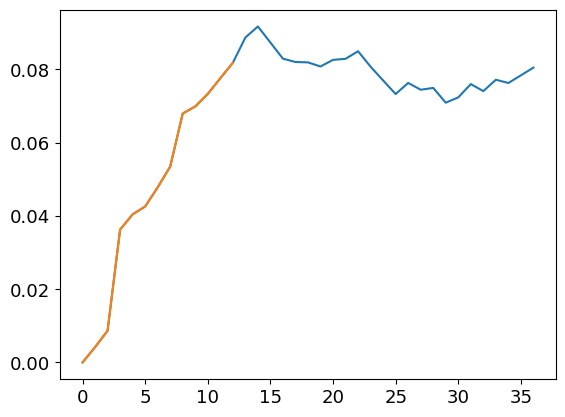

In [159]:
plt.plot(control.wres[0])
plt.plot(wres[0])

In [136]:
test =  (stats.qtten5000.values/(stats.dth0mean5000.values/stats.dzmean5000))

In [189]:
plt.plot(time, abs(stats.wmean5000.values - stats.wtgmean5000.values))
#plt.plot(time, stats.dth0mean5000.values)

#plt.plot(mtime, qt[0])

#plt.plot(time,test)
plt.plot(mtime, wres[0])

#plt.plot(control.time.values, control.wres[0])
##plt.plot(tarr, prs)

plt.xlim(-1, 61)

plt.title('mean 5000 m AGL abs(w residual)')


AttributeError: 'Dataset' object has no attribute 'wtgmean5000'

In [181]:

stats = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test/member001/cm1out_stats.nc')
time=stats.time.values.astype(int)/1e9/60.0
stats

/tmp/ipykernel_2109467/585682972.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  stats = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test/member001/cm1out_stats.nc')


<xarray.Dataset> Size: 437kB
Dimensions:       (xh: 1, yh: 1, zh: 1, time: 1201)
Coordinates:
  * xh            (xh) float32 4B 0.0
  * yh            (yh) float32 4B 0.0
  * zh            (zh) float32 4B 0.0
  * time          (time) timedelta64[ns] 10kB 00:00:00 00:00:06 ... 02:00:00
Data variables: (12/89)
    mtime         (time) float32 5kB ...
    wmax          (time) float32 5kB ...
    wmin          (time) float32 5kB ...
    zwmax         (time) float32 5kB ...
    zwmin         (time) float32 5kB ...
    wmax500       (time) float32 5kB ...
    ...            ...
    vortsfc       (time) float32 5kB ...
    vort1km       (time) float32 5kB ...
    vort2km       (time) float32 5kB ...
    vort3km       (time) float32 5kB ...
    vort4km       (time) float32 5kB ...
    vort5km       (time) float32 5kB ...
Attributes:
    CM1 version:    cm1r21.1
    Conventions:    CF-1.7
    missing_value:  -999999.9

In [80]:
control = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/WTG.nc')
control

<xarray.Dataset> Size: 22kB
Dimensions:  (t: 37, ne: 36)
Coordinates:
  * t        (t) int64 296B 0 1 2 3 4 5 6 7 8 9 ... 28 29 30 31 32 33 34 35 36
  * ne       (ne) int64 288B 0 1 2 3 4 5 6 7 8 9 ... 27 28 29 30 31 32 33 34 35
Data variables:
    time     (t) int64 296B ...
    wres     (ne, t) float64 11kB ...
    qr       (ne, t) float64 11kB ...

Text(0, 0.5, 'm/s')

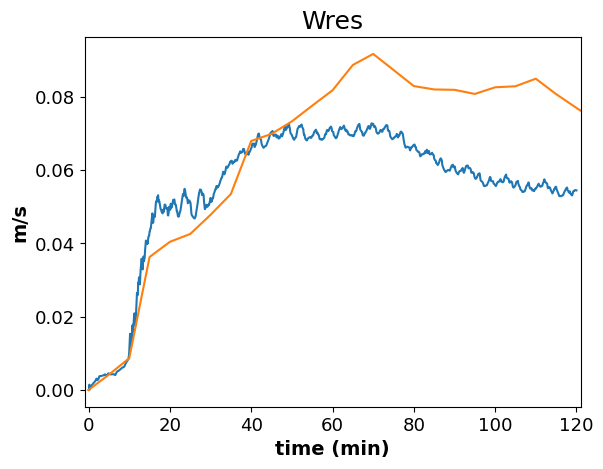

In [192]:
#plt.plot(time, stats.wmax5000.values)
plt.plot(time, (stats.wresmean5000.values ))
#plt.plot(time, test)

#plt.plot(mtime, wres[0])
plt.plot(control.time.values, control.wres[0])
#plt.plot(tarr, prs)

plt.xlim(-1, 121)

plt.title('Wres')
plt.xlabel('time (min)')
plt.ylabel('m/s')

Text(0, 0.5, 'g/kg')

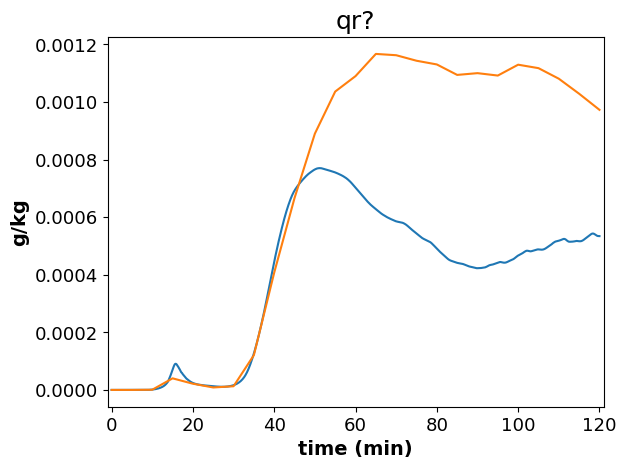

In [193]:
plt.plot(time, stats.qrmean.values*1000 )

plt.plot(mtime, qr[0]*1000)
#plt.plot(tarr, prs)

plt.xlim(-1, 121)
#plt.ylim(0, 0.0002)

plt.title('qr?')
plt.xlabel('time (min)')
plt.ylabel('g/kg')


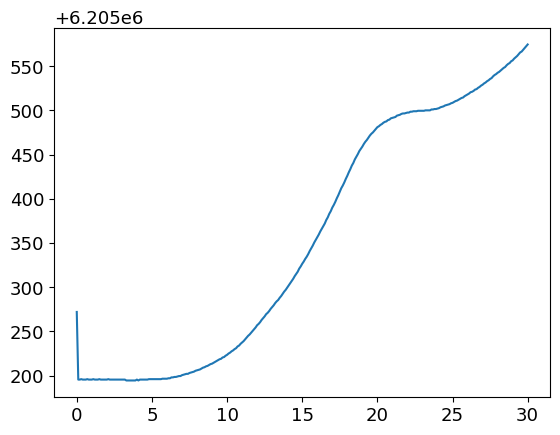

In [76]:
plt.plot(time, tmoist/(128*128*51)/3000)
#plt.plot(tarr, qr[0])

In [70]:
stats = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test_2025-05-14_17:56:21.954156/member001/cm1out_stats.nc')


tmoist = stats.tmois.values

/tmp/ipykernel_2109467/588835943.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  stats = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test_2025-05-14_17:56:21.954156/member001/cm1out_stats.nc')


/tmp/ipykernel_2109467/1397643147.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  stats = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test/member001/cm1out_stats.nc')


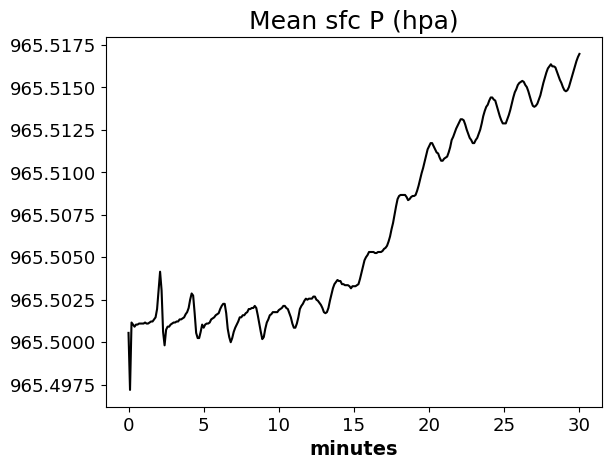

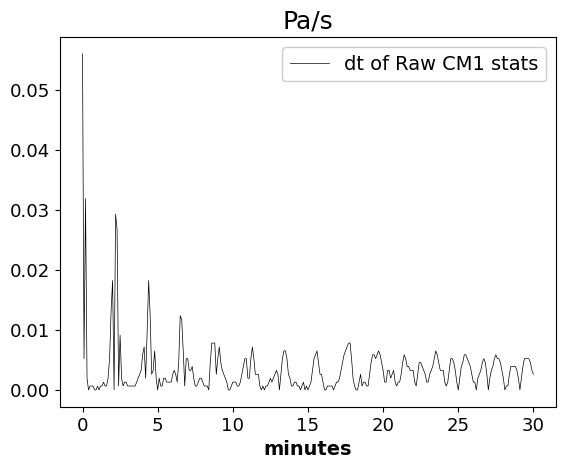

In [32]:
stats = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/stat_test/member001/cm1out_stats.nc')
time=stats.time.values.astype(int)/1e9/60.0
#plt.plot(stats.divmax/(128*128))
fig = plt.figure()
#plt.plot(time, stats.psfcmin.values, label='Raw CM1 stats', color='k')#*(299792458**2)/100)
plt.plot(time, stats.psfcmean.values/100, label='Raw CM1 stats', color='k')
# plt.plot(tarr, np.array(prs)/100, label= 'python np.mean() of restart file')
# plt.plot(tarr, np.array(prsum)/100,label= 'python sum()/N of restart file')

#plt.ylim(957.4,957.48)
plt.title('Mean sfc P (hpa)')
plt.xlabel('minutes')
#plt.legend(loc=2, fontsize=14)

fig = plt.figure()
plt.plot(time, abs(np.gradient(stats.psfcmean.values, 6)), color='k', lw=.5,label='dt of Raw CM1 stats')

# plt.plot(tarr, abs(np.gradient(prs, 300)), label= 'dt of python np.mean()')
# plt.plot(tarr, abs(np.gradient(prsum, 300)),label= 'dt of python sum()/N')

#hdiv = stats.divmax.values/(128*128)

#plt.plot(time, (343**2) * (hdiv))


plt.title('Pa/s')
plt.xlabel('minutes')
plt.legend(fontsize=14)

In [65]:
stats

<xarray.Dataset> Size: 105kB
Dimensions:      (xh: 1, yh: 1, zh: 1, time: 301)
Coordinates:
  * xh           (xh) float32 4B 0.0
  * yh           (yh) float32 4B 0.0
  * zh           (zh) float32 4B 0.0
  * time         (time) timedelta64[ns] 2kB 00:00:00 00:00:06 ... 00:30:00
Data variables: (12/85)
    mtime        (time) float32 1kB ...
    wmax         (time) float32 1kB ...
    wmin         (time) float32 1kB ...
    zwmax        (time) float32 1kB ...
    zwmin        (time) float32 1kB ...
    wmax500      (time) float32 1kB ...
    ...           ...
    vortsfc      (time) float32 1kB ...
    vort1km      (time) float32 1kB ...
    vort2km      (time) float32 1kB ...
    vort3km      (time) float32 1kB ...
    vort4km      (time) float32 1kB ...
    vort5km      (time) float32 1kB ...
Attributes:
    CM1 version:    cm1r21.1
    Conventions:    CF-1.7
    missing_value:  -999999.9

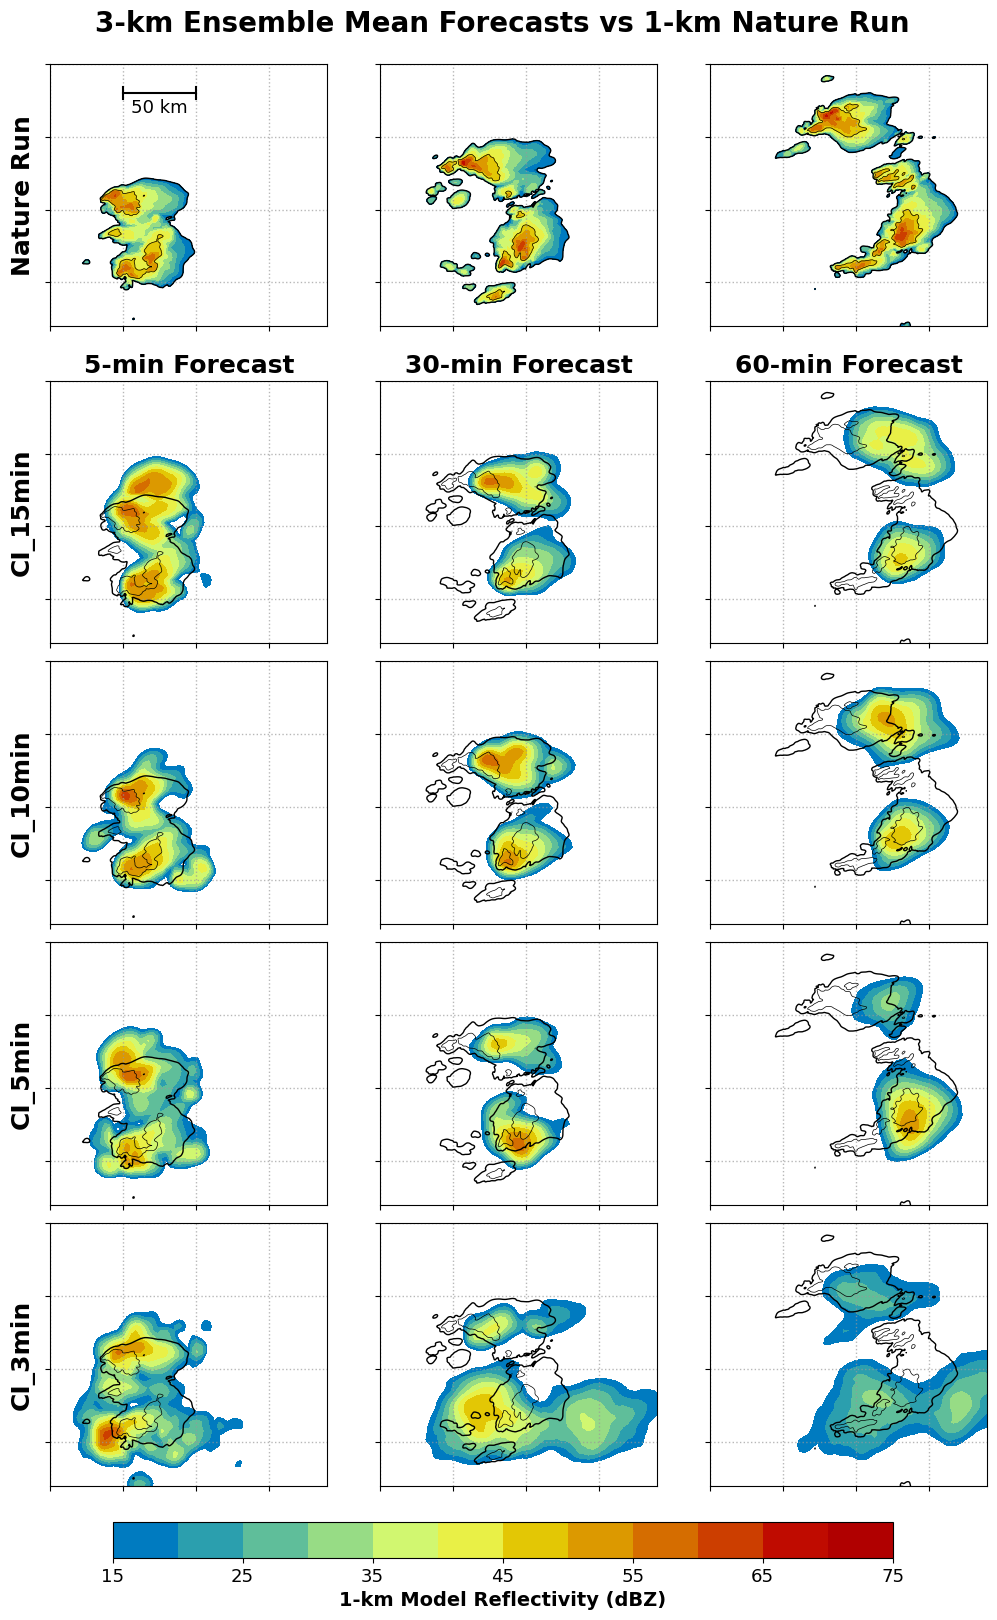

In [25]:
fig, axes = plt.subplots(5,3, figsize=(13, 18), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

times = [dt.datetime(2024,5,8,21,35), dt.datetime(2024,5,8,22), dt.datetime(2024,5,8,22,30)]
exps = ['CI_15min', 'CI_10min', 'CI_5min', 'CI_3min']


height = 1 # km

# get info for nature run
with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}/{exps[0]}.exp', 'rb') as f: exper = json.load(f)
start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
fcst_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')

for ni, exp in enumerate(exps):
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc')
    cm1t = [pd.Timestamp(t) for t in cm1.time.values ]

    xh, yh, z = cm1.xh.values, cm1.yh.values, cm1.z.values

    axes[ni+1, 0].set_ylabel(exp, fontsize=18)

    for ti,time in enumerate(times):
        cti = findnearest(cm1t, time)
        axes[ ni+1, ti].contourf(xh, yh, cm1.dbz[cti,-1, findnearest(z, height)],  cmap=ctables.REF_default, levels=np.arange(15,80,5))
        
        fcst_len = int((time - fcst_start).seconds/60)
        if ni == 0:
            axes[ni+1, ti].set_title(f'{fcst_len}-min Forecast', weight='bold')
    cm1.close()

for ti,time in enumerate(times):
    tt = int((time-start).seconds/60)-10
    NR = xr.open_dataset(f'/scratch/home/jessica.mcdonald/NR_500m_may8/cm1out_{tt:06d}.nc', decode_timedelta=True)
    im=axes[0, ti].contourf(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)],  cmap=ctables.REF_default, levels=np.arange(15,80,5))
    for ax in axes[:, ti]:
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[15], linewidths=1)
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[45], linewidths=0.5)
    NR.close()
axes[0,0].set_ylabel('Nature Run', fontsize=18)

for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

# add in length scale
axes[0,0].plot([200,250], [280,280], color='k')
axes[0,0].plot([200,200], [276,284], color='k')
axes[0,0].plot([250,250], [276,284], color='k')
axes[0,0].text(225, 276, '50 km', ha='center', va='top', fontsize=13)

cbar_ax = fig.add_axes([0.2, 0.07, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('1-km Model Reflectivity (dBZ)', weight='bold')
plt.subplots_adjust(wspace=0.2, hspace=0.3)

# set limits and adjust plot
axes[0,0].set_xlim(150, 340)
axes[0,0].set_ylim(120, 300)
plt.subplots_adjust(hspace=0.07, wspace=-0.05)


for ax in axes[0,:]:
    pos = ax.get_position()
    pos.y0 = pos.y0 +.02
    pos.y1 = pos.y1 +.02
    ax.set_position(pos)
fig.canvas.draw()

fig.suptitle('3-km Ensemble Mean Forecasts vs 1-km Nature Run', y=.93, fontsize=20, weight='bold');



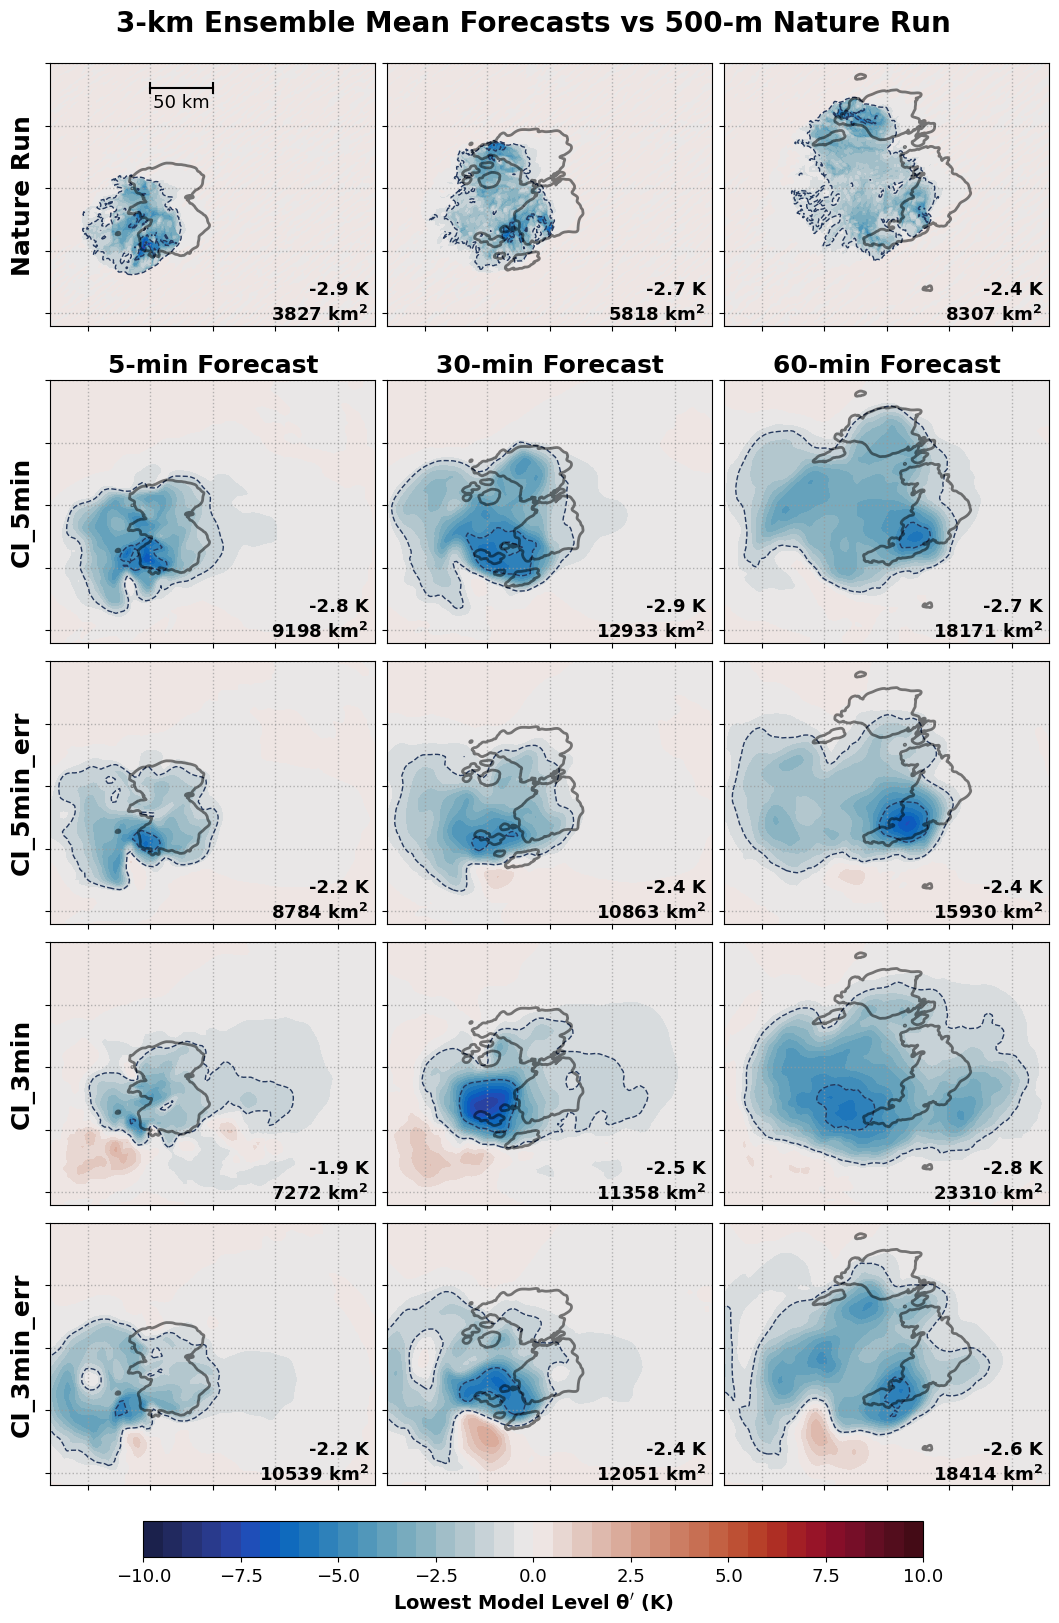

In [79]:


times = [dt.datetime(2024,5,8,21,35), dt.datetime(2024,5,8,22), dt.datetime(2024,5,8,22,30)]
exps = ['CI_15min', 'CI_10min', 'CI_5min', 'CI_3min']
exps = [ 'CI_5min', 'CI_5min_err','CI_3min', 'CI_3min_err',]


if len(exps)==4:
    fig, axes = plt.subplots(5,3, figsize=(13, 18), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
if len(exps)==5:
    fig, axes = plt.subplots(4,3, figsize=(11, 14), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

height = 0 # km

# get info for nature run
with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}/{exps[0]}.exp', 'rb') as f: exper = json.load(f)
start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
fcst_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')

for ni, exp in enumerate(exps):
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc')
    cm1t = [pd.Timestamp(t) for t in cm1.time.values ]
    xh, yh, z = cm1.xh.values, cm1.yh.values, cm1.z.values

    thp = (cm1.th[:, -1] - cm1.th[:,-1,:,-1].mean(axis=2)).values

    axes[ni+1, 0].set_ylabel(exp, fontsize=18)

    for ti,time in enumerate(times):
        cti = findnearest(cm1t, time)
        axes[ ni+1, ti].contourf(xh, yh, thp[cti, findnearest(z, height)],  cmap=cmaps.balance, levels=np.arange(-10, 10.1, .5))
        axes[ ni+1, ti].contour(xh, yh, thp[cti, findnearest(z, height)], colors='#25395e',linestyles='--', levels=[-10, -5, -1], linewidths=1)

        mean_temp = thp[cti, findnearest(z, height)]
        mean_temp = np.mean(mean_temp[mean_temp <= -1])
        cp_size = np.count_nonzero(thp[cti,findnearest(z, height)] <= -1)*(3*3)

        axes[ ni+1, ti].text(0.98, 0.02, f"{cp_size:.0f} km"+r'$\mathbf{^2}$', ha='right',fontsize=13, weight='bold', transform=axes[ ni+1, ti].transAxes)
        axes[ ni+1, ti].text(0.98, 0.12, f"{mean_temp:.1f} K", ha='right',fontsize=13, weight='bold', transform=axes[ ni+1, ti].transAxes)
        
        fcst_len = int((time - fcst_start).seconds/60)
        if ni == 0:
            axes[ni+1, ti].set_title(f'{fcst_len}-min Forecast', weight='bold')
        cm1.close()

for ti,time in enumerate(times):
    tt = int((time-start).seconds/60)-10
    NR = xr.open_dataset(f'/scratch/home/jessica.mcdonald/NR_500m_may8/cm1out_{tt:06d}.nc', decode_timedelta=True)
    thp = (NR.th - NR.th[:,:,:,-1].mean(axis=2)).values
    im=axes[0, ti].contourf(NR.xh, NR.yh, thp[0,findnearest(NR.zh, height)],  cmap=cmaps.balance, levels=np.arange(-10, 10.1, .5))
    axes[0, ti].contour(NR.xh, NR.yh, thp[0,findnearest(NR.zh, height)], colors='#25395e',linestyles='--', levels=[-10, -5, -1], linewidths=1)

    mean_temp = thp[0, findnearest(NR.zh, height)]
    mean_temp = np.mean(mean_temp[mean_temp <= -1])

    cp_size = np.count_nonzero(thp[0,findnearest(NR.zh, height)] <= -1)*(.5*.5)
    
    axes[0, ti].text(0.98, 0.12, f"{mean_temp:.1f} K", ha='right',fontsize=13, weight='bold', transform=axes[ 0, ti].transAxes)
    axes[0, ti].text(0.98, 0.02,f"{cp_size:.0f} km"+r'$\mathbf{^2}$', ha='right',fontsize=13, weight='bold', transform=axes[ 0, ti].transAxes)
   
    NR.close()

    for ax in axes[:, ti]:
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[15], linewidths=2, alpha=0.5)
        #ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[45], linewidths=0.5)
        #ax.contour(NR.xh, NR.yh, thp[0,findnearest(NR.zh, height)], colors='#25395e',linestyles='--', levels=[-100, -1], linewidths=1)
    
axes[0,0].set_ylabel('Nature Run', fontsize=18)

for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

# add in length scale
axes[0,0].plot([200,250], [280,280], color='k')
axes[0,0].plot([200,200], [276,284], color='k')
axes[0,0].plot([250,250], [276,284], color='k')
axes[0,0].text(225, 276, '50 km', ha='center', va='top', fontsize=13)

cbar_ax = fig.add_axes([0.2, 0.07, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label(r'Lowest Model Level $\mathbf{\theta^{\prime}}$ (K)', weight='bold')
plt.subplots_adjust(wspace=0.2, hspace=0.3)

# set limits and adjust plot
axes[0,0].set_xlim(120, 380)
axes[0,0].set_ylim(90, 300)
plt.subplots_adjust(hspace=0.07, wspace=0.01)


for ax in axes[0,:]:
    pos = ax.get_position()
    pos.y0 = pos.y0 +.02
    pos.y1 = pos.y1 +.02
    ax.set_position(pos)
fig.canvas.draw()

fig.suptitle('3-km Ensemble Mean Forecasts vs 500-m Nature Run', y=.93, fontsize=20, weight='bold');

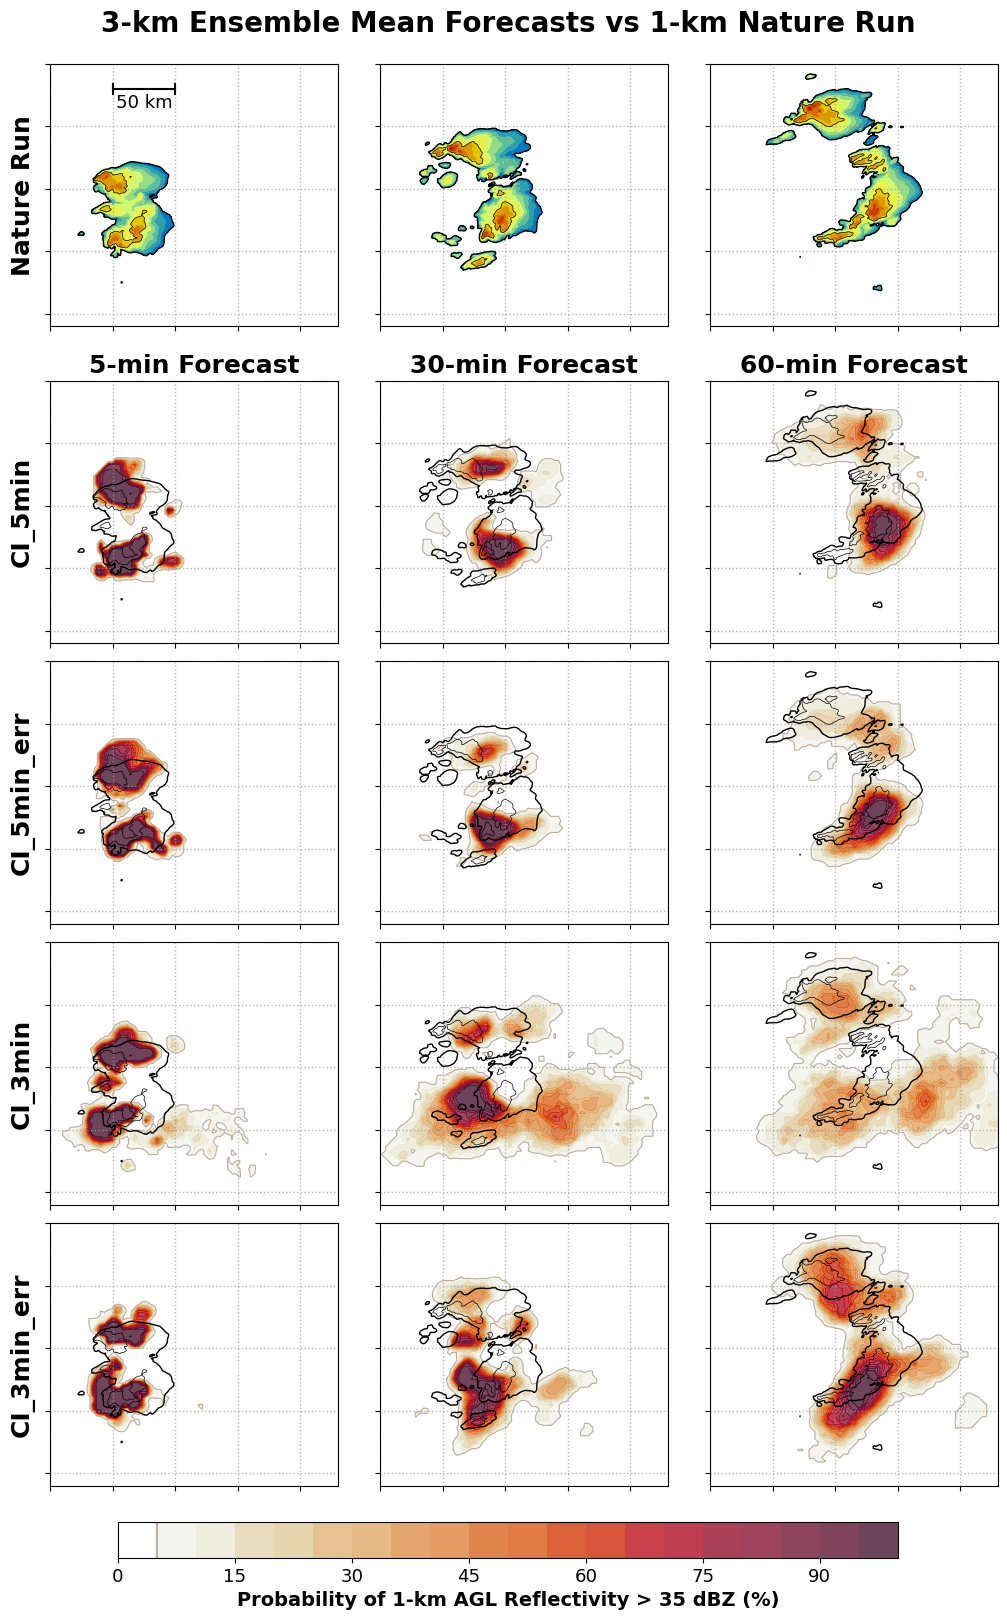

In [6]:

exps = ['CI_15min', 'CI_10min', 'CI_5min', 'CI_3min']
exps = ['CI_3min_err', 'CI_3min_inlier', 'CI_3min']

exps = [ 'CI_3min', 'CI_3min_err','CI_3min_err_inlier', 'CI_3min_inlier',]
exps = [ 'CI_5min', 'CI_5min_err','CI_3min', 'CI_3min_err',]


if len(exps)==4:
    fig, axes = plt.subplots(5,3, figsize=(13, 18), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
if len(exps)==3:
    fig, axes = plt.subplots(4,3, figsize=(11, 14), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

times = [dt.datetime(2024,5,8,21,35), dt.datetime(2024,5,8,22), dt.datetime(2024,5,8,22,30)]

height = 1   # km
threshold=35 # dbz

#cmap = concat([])

cmap_b = cmaps.sunburst_r.cut(.2, 'right')
clist = [to_rgb('#ffffff')]
clist.extend(cmap_b(np.linspace(0,1,49)))
cmap1 = LinearSegmentedColormap.from_list("CR", clist, 30)



# get info for nature run
with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}/{exps[0]}.exp', 'rb') as f: exper = json.load(f)
start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
fcst_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')

for ni, exp in enumerate(exps):
    cm1 = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc", decode_timedelta=True)
    cm1t = [pd.Timestamp(t) for t in cm1.time.values ]

    xh, yh, z = cm1.xh.values, cm1.yh.values, cm1.z.values
    ensN = int(cm1.ne.max()) #this is zero based, so it excludes the mean which is the final member


    axes[ni+1, 0].set_ylabel(exp, fontsize=18)

    for ti,time in enumerate(times):
        cti = findnearest(cm1t, time)
        dbz_field = cm1['dbz'][cti, :-1, findnearest(z, height)].values
        probs = np.zeros_like(dbz_field)
        probs[dbz_field >= threshold] = 1
        
        probs = probs.sum(axis=0)/ensN
        im = axes[ ni+1, ti].contourf(xh, yh, probs*100,  cmap=cmap1, levels=np.arange(0, 105, 5), alpha=0.8)
        axes[ni+1, ti].contour(xh, yh, probs*100,  colors='#bdad9b', levels=[5], linewidths=0.8)
        
        fcst_len = int((time - fcst_start).seconds/60)
        if ni == 0:
            axes[ni+1, ti].set_title(f'{fcst_len}-min Forecast', weight='bold')
    cm1.close()

for ti,time in enumerate(times):
    tt = int((time-start).seconds/60)-10
    NR = xr.open_dataset(f'/scratch/home/jessica.mcdonald/NR_500m_may8/cm1out_{tt:06d}.nc', decode_timedelta=True)
    axes[0, ti].contourf(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)],  cmap=ctables.REF_default, levels=np.arange(15,80,5))
    for ax in axes[:, ti]:
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[15], linewidths=1)
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[45], linewidths=0.5)
    NR.close()
axes[0,0].set_ylabel('Nature Run', fontsize=18)

for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

# add in length scale
axes[0,0].plot([200,250], [280,280], color='k')
axes[0,0].plot([200,200], [276,284], color='k')
axes[0,0].plot([250,250], [276,284], color='k')
axes[0,0].text(225, 276, '50 km', ha='center', va='top', fontsize=13)

cbar_ax = fig.add_axes([0.2, 0.07, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Probability of 1-km AGL Reflectivity > 35 dBZ (%)', weight='bold')
cbar.ax.axvline(5,color='#bdad9b' )

plt.subplots_adjust(wspace=0.2, hspace=0.3)

# set limits and adjust plot
axes[0,0].set_xlim(150, 380)
axes[0,0].set_ylim(90, 300)
plt.subplots_adjust(hspace=0.07, wspace=-0.05)


for ax in axes[0,:]:
    pos = ax.get_position()
    pos.y0 = pos.y0 +.02
    pos.y1 = pos.y1 +.02
    ax.set_position(pos)
fig.canvas.draw()

fig.suptitle('3-km Ensemble Mean Forecasts vs 500-m Nature Run', y=.93, fontsize=20, weight='bold');



<built-in method max of numpy.ndarray object at 0x7fcb2ea6ba50>
<built-in method max of numpy.ndarray object at 0x7fcb38564b10>
<built-in method max of numpy.ndarray object at 0x7fcb2efb7c90>
<built-in method max of numpy.ndarray object at 0x7fcb2ead47b0>
<built-in method max of numpy.ndarray object at 0x7fcb2ead4930>
<built-in method max of numpy.ndarray object at 0x7fcb2e5d2250>
<built-in method max of numpy.ndarray object at 0x7fcb2ead4b70>
<built-in method max of numpy.ndarray object at 0x7fcb2e5d1bf0>
<built-in method max of numpy.ndarray object at 0x7fcb2e5ed7d0>


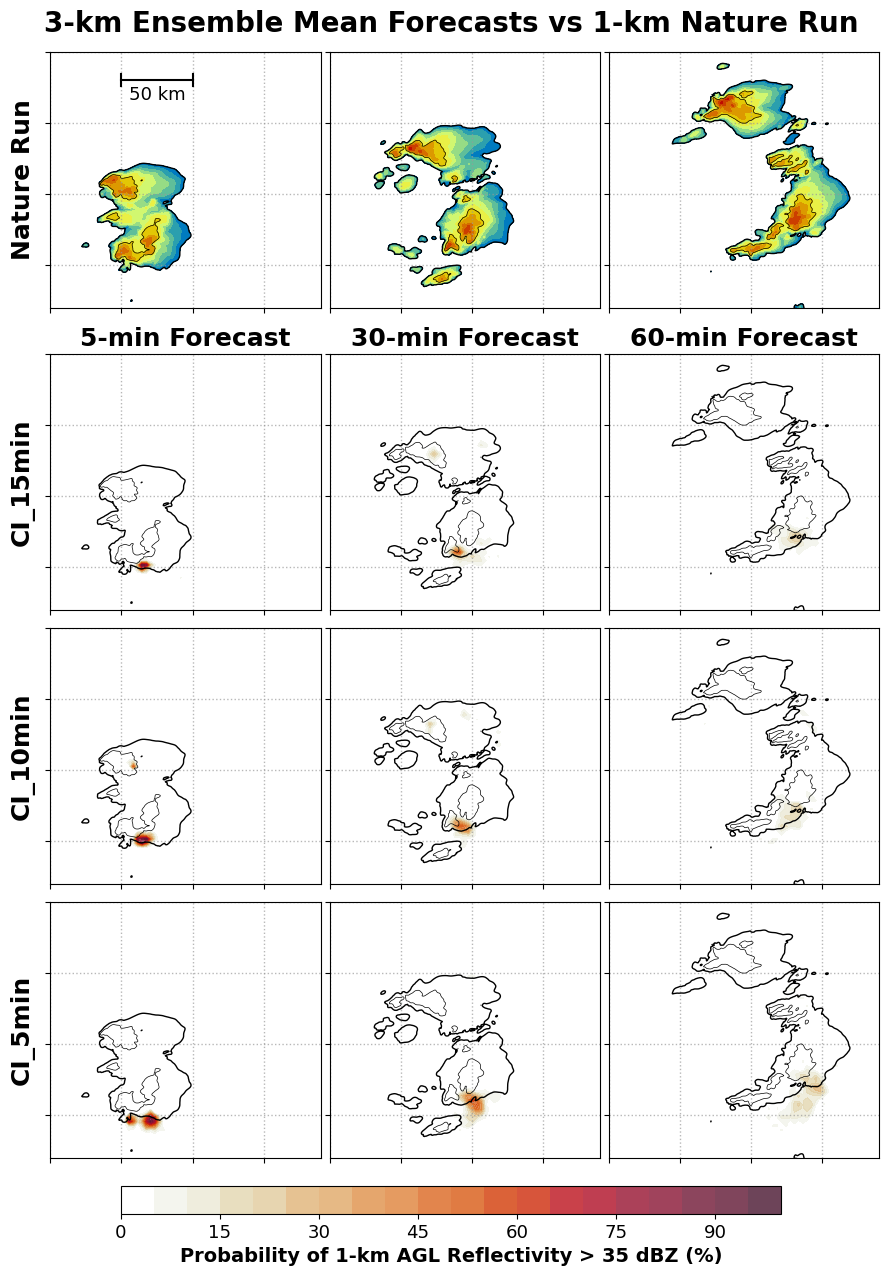

In [109]:
fig, axes = plt.subplots(4,3, figsize=(11, 14), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

times = [dt.datetime(2024,5,8,21,35), dt.datetime(2024,5,8,22), dt.datetime(2024,5,8,22,30)]
exps = ['CI_15min', 'CI_10min', 'CI_5min']

height = 1   # km
threshold=100 # m2 s-2

#cmap = concat([])

cmap_b = cmaps.sunburst_r.cut(.2, 'right')
clist = [to_rgb('#ffffff')]
clist.extend(cmap_b(np.linspace(0,1,49)))
cmap1 = LinearSegmentedColormap.from_list("CR", clist, 30)

# get info for nature run
with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}/{exps[0]}.exp', 'rb') as f: exper = json.load(f)
start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
fcst_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')

for ni, exp in enumerate(exps):
    cm1 = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc", decode_timedelta=True)
    cm1t = [pd.Timestamp(t) for t in cm1.time.values ]

    xh, yh, z = cm1.xh.values, cm1.yh.values, cm1.z.values
    ensN = int(cm1.ne.max()) #this is zero based, so it excludes the mean which is the final member


    axes[ni+1, 0].set_ylabel(exp, fontsize=18)

    for ti,time in enumerate(times):
        cti = findnearest(cm1t, time)

        ztop = findnearest(z, 5)
        zbot = findnearest(z, 2)
        
        vert_vel = cm1['w'][cti, :-1, zbot:ztop+1].values
        u        = cm1['u'][cti, :-1, zbot:ztop+1].values
        v        = cm1['v'][cti, :-1, zbot:ztop+1].values
        
        
        dx = np.gradient(cm1.xh)*1000
        dy = np.gradient(cm1.yh)*1000
        dz  = np.gradient(cm1.z)[zbot:ztop+1]*1000
        
        dudy = np.gradient(u, axis=2)/dy#[:,np.newaxis,:, np.newaxis]
        dvdx = np.gradient(v, axis=3)/dx#[:,np.newaxis,   np.newaxis,:]
        zeta = dvdx-dudy
        
        UH = np.sum(zeta*vert_vel*dz[np.newaxis, :, np.newaxis, np.newaxis], axis=1)

        print(UH.max)

        probs = np.zeros_like(UH)
        probs[UH >= threshold] = 1
        
        probs = probs.sum(axis=0)/ensN
        im = axes[ ni+1, ti].contourf(xh, yh, probs*100,  cmap=cmap1, levels=np.arange(0, 105, 5), alpha=0.8)
        
        fcst_len = int((time - fcst_start).seconds/60)
        if ni == 0:
            axes[ni+1, ti].set_title(f'{fcst_len}-min Forecast', weight='bold')
    cm1.close()

for ti,time in enumerate(times):
    tt = int((time-start).seconds/60)-10
    NR = xr.open_dataset(f'/scratch/home/jessica.mcdonald/NR_500m_may8/cm1out_{tt:06d}.nc', decode_timedelta=True)
    axes[0, ti].contourf(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)],  cmap=ctables.REF_default, levels=np.arange(15,80,5))
    for ax in axes[:, ti]:
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[15], linewidths=1)
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[45], linewidths=0.5)
    NR.close()
axes[0,0].set_ylabel('Nature Run', fontsize=18)

for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

# add in length scale
axes[0,0].plot([200,250], [280,280], color='k')
axes[0,0].plot([200,200], [276,284], color='k')
axes[0,0].plot([250,250], [276,284], color='k')
axes[0,0].text(225, 276, '50 km', ha='center', va='top', fontsize=13)

cbar_ax = fig.add_axes([0.2, 0.07, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Probability of 1-km AGL Reflectivity > 35 dBZ (%)', weight='bold')
plt.subplots_adjust(wspace=0.2, hspace=0.3)

# set limits and adjust plot
axes[0,0].set_xlim(150, 340)
axes[0,0].set_ylim(120, 300)
plt.subplots_adjust(hspace=0.07, wspace=-0.05)


for ax in axes[0,:]:
    pos = ax.get_position()
    pos.y0 = pos.y0 +.02
    pos.y1 = pos.y1 +.02
    ax.set_position(pos)
fig.canvas.draw()

fig.suptitle('3-km Ensemble Mean Forecasts vs 1-km Nature Run', y=.93, fontsize=20, weight='bold');



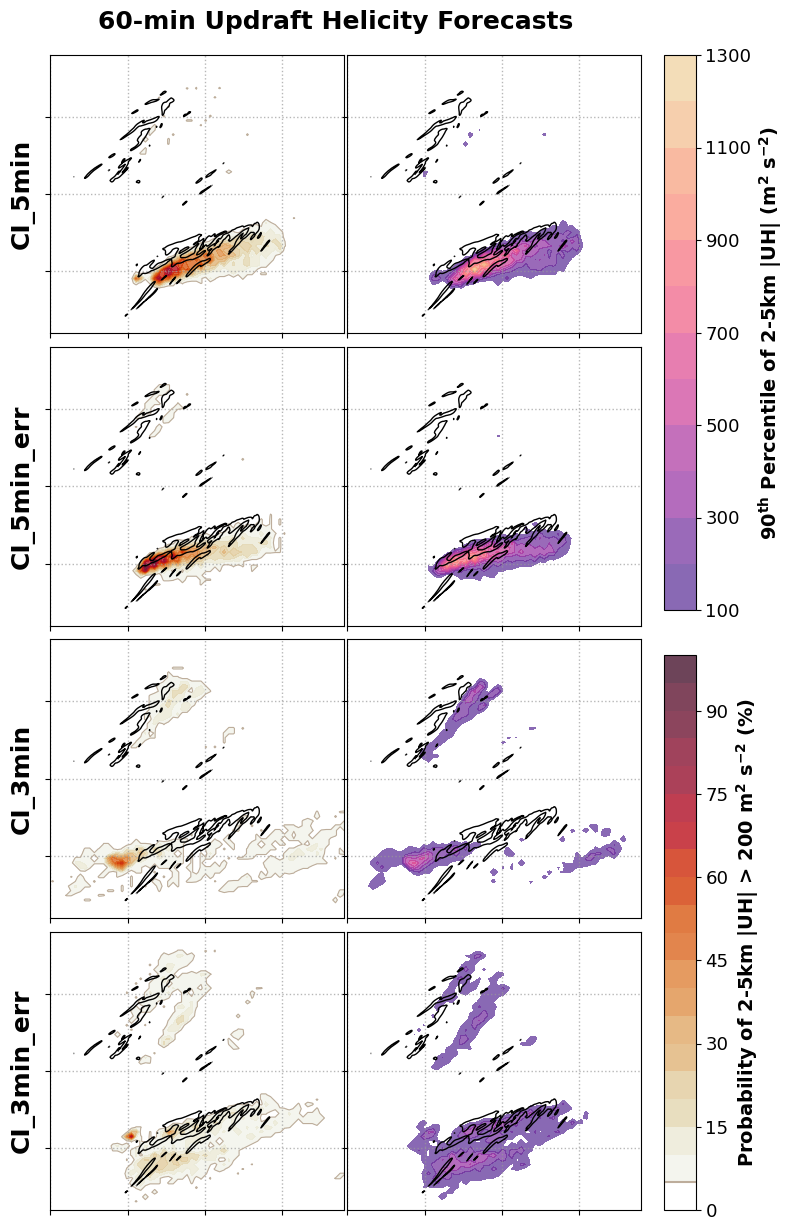

In [7]:
fig, axes = plt.subplots(4,2, figsize=(8, 15), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})


#fig, axes = plt.subplots(3,2, figsize=(8, 12), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

time = dt.datetime(2024,5,8,21,35)
exps = ['CI_15min', 'CI_10min', 'CI_5min', 'CI_3min']
exps = ['CI_3min_err', 'CI_3min_inlier', 'CI_3min']

exps = [ 'CI_3min', 'CI_3min_err','CI_3min_err_inlier', 'CI_3min_inlier',]
exps = [ 'CI_5min', 'CI_5min_err','CI_3min', 'CI_3min_err',]

height = 1   # km
threshold=200 # m2 s-2

#cmap = concat([])

cmap_b = cmaps.sunburst_r.cut(.2, 'right')
clist = [to_rgb('#ffffff')]
clist.extend(cmap_b(np.linspace(0,1,49)))
cmap1 = LinearSegmentedColormap.from_list("CR", clist, 30)

# cmap_b = cmaps.brwnyl#.cut(.2, 'right')
# clist = [to_rgb('#ffffff'),to_rgb('#ffffff')]
# clist.extend(cmap_b(np.linspace(0,1,7)))
# cmap2 = LinearSegmentedColormap.from_list("CR", clist, 30)

cmap_b = cmaps.agsunset#.cut(.2, 'right')
clist = []
clist.extend(cmap_b(np.linspace(0,1,7)))
cmap2 = LinearSegmentedColormap.from_list("CR", clist, 30)

# get info for nature run
with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}/{exps[0]}.exp', 'rb') as f: exper = json.load(f)
start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')

#fcst_start = dt.datetime.strptime(exper['DA_PARAMS'['DA_end_time'], '%Y-%m-%d %H:%M:%S')


cmap_b = cmaps.sunburst_r.cut(.2, 'right')
clist = [to_rgb('#ffffff')]
clist.extend(cmap_b(np.linspace(0,1,49)))
cmap1 = LinearSegmentedColormap.from_list("CR", clist, 30)



for ni, exp in enumerate(exps):
    cm1 = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc", decode_timedelta=True)
    cm1t = [pd.Timestamp(t) for t in cm1.time.values ]

    xh, yh, z = cm1.xh.values, cm1.yh.values, cm1.z.values
    ensN = int(cm1.ne.max()) #this is zero based, so it excludes the mean which is the final member

    axes[ni, 0].set_ylabel(exp, fontsize=18)

    ztop = findnearest(z, 5)
    zbot = findnearest(z, 2)
    
    vert_vel = cm1['w'][:, :-1, zbot:ztop+1].values
    u        = cm1['u'][:, :-1, zbot:ztop+1].values
    v        = cm1['v'][:, :-1, zbot:ztop+1].values
    
    
    dx = np.gradient(cm1.xh)*1000
    dy = np.gradient(cm1.yh)*1000
    dz  = np.gradient(cm1.z)[zbot:ztop+1]*1000
    
    dudy = np.gradient(u, axis=3)/dy#[:,np.newaxis,:, np.newaxis]
    dvdx = np.gradient(v, axis=4)/dx#[:,np.newaxis,   np.newaxis,:]
    zeta = dvdx-dudy
    
    UH = np.abs(np.sum(zeta*vert_vel*dz[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis], axis=2))
    UH_90 = np.max(np.percentile(UH, 90, axis=1), axis=0)
    
    probs = np.zeros_like(UH)
    probs[UH >= threshold] = 1
    
    probs = probs.sum(axis=1)
    probs = probs.max(axis=0)/ensN
    #print(np.max(probs))

    im1=axes[ni, 0].contourf(xh, yh, probs*100,  cmap=cmap1, levels=np.arange(0, 105, 5), alpha=0.8)
    axes[ni, 0].contour(xh, yh, probs*100,  colors='#bdad9b', levels=[5], linewidths=0.8)
    im2=axes[ni, 1].contourf(xh, yh, UH_90,  cmap=cmap2, levels=np.arange(100, 1400, 100), alpha=0.7)

    cm1.close()

### add in nature run stuff
tt0 = int((cm1t[0]-start).seconds/60)-10
tt1 = int((cm1t[-1]-start).seconds/60)-10
NR_start = xr.open_dataset(f'/scratch/home/jessica.mcdonald/NR_500m_may8/cm1out_{tt0:06d}.nc', decode_timedelta=True)
NR_end = xr.open_dataset(f'/scratch/home/jessica.mcdonald/NR_500m_may8/cm1out_{tt1:06d}.nc', decode_timedelta=True)

Nxh, Nyh = NR_end.xh.values, NR_start.yh.values
NR_UH = (NR_end['shs'][0,:,:] - NR_start['shs'][0,:,:]).values

for ax in axes.flatten():
    ax.contour(Nxh, Nyh, NR_UH, levels=[400], colors='k', linewidths=1)
    ax.set_xlim(150, 340)
    ax.set_ylim(110,290)
    ax.set_yticks(np.arange(150, 300, 50))
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

#### you're gonna have to calculate the UH swath yourself.... 
## or just do max UH? and subtract the start from the end, and ajdust your code above too. idk. figure it out on wednesday
NR_start.close()
NR_end.close()

plt.subplots_adjust(hspace=0.05, wspace=-0.08)


cbar_ax1 = fig.add_axes([0.91, 0.11, 0.04, 0.37])
cbar1 = fig.colorbar(im1, cax=cbar_ax1)
cbar1.set_label('Probability of 2-5km |UH| > 200 m$\mathbf{^2}$ s$\mathbf{^{-2}}$ (%)', weight='bold')
cbar1.ax.axhline(5,color='#bdad9b' )

cbar_ax2 = fig.add_axes([0.91, 0.51, 0.04, 0.37])
cbar2 = fig.colorbar(im2, cax=cbar_ax2)
cbar2.set_label('90$\mathbf{^{th}}$ Percentile of 2-5km |UH| (m$\mathbf{^2}$ s$\mathbf{^{-2}}$)', weight='bold')

fig.suptitle('60-min Updraft Helicity Forecasts', y=.91, fontsize=18, weight='bold');

In [14]:
{'VR':4.24, 'DBZ':9.899, 'DBZ0':7.071, 'DBZ0_W': 0.5} 
# 3, 7 5

In [5]:
3.0 *np.sqrt(2)

np.float64(4.242640687119286)

In [2]:
import numpy as np

In [122]:
probs = np.zeros_like(UH)
probs[UH >= threshold] = 1

probs = probs.sum(axis=1)
probs = probs.max(axis=0)

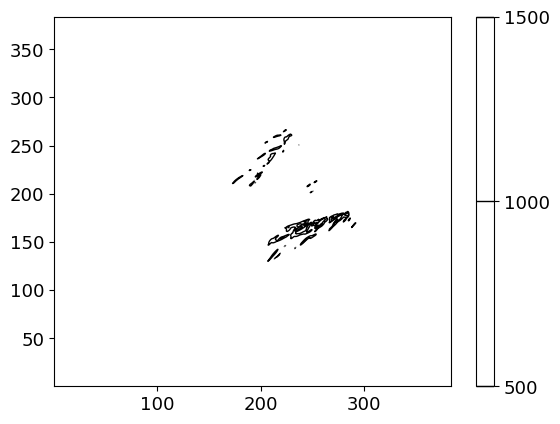

In [20]:
plt.contour(Nxh, Nyh, NR_UH, levels=[500,1000,1500], colors='k', linewidths=1)
plt.colorbar()

In [142]:
np.shape(UH)

(12, 12, 128, 128)

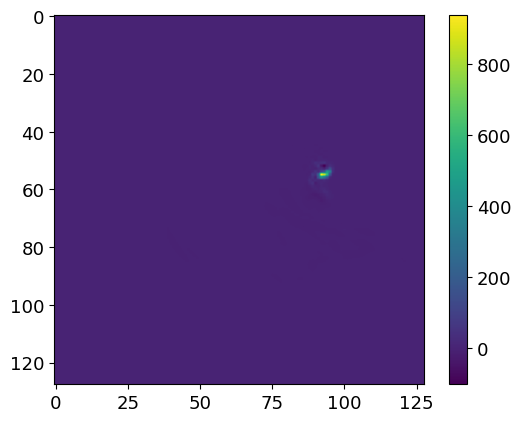

In [98]:
plt.imshow(UH[33])
plt.colorbar()

# Creating better posterior/prior code

In [5]:
import os
import numpy as N
import math as M
import datetime as DT 
from netCDF4 import *
import pyDart
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *

import json
import src.plot_src.ctables as ctables

from pyDart import dxy_2_dll
import pandas as pd
import pickle
import numpy as np
import cftime


day_utime   = "days since 1601-01-01 00:00:00"
sec_utime   = "seconds since 1970-01-01 00:00:00"

import sys
import ens
from ens import calcHx
import pandas as pd
import state_vector as state_vector
import datetime as DT
import json
import numpy as np


In [7]:

#fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_outliers/'
fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_noref/'
name = fpath.split('/')[-2]

analysis_time = DT.datetime(2024, 5, 8, 20)

sec_utime = "seconds since 1970-01-01 00:00:00"
with open(f'{fpath}{name}.exp', 'rb') as f:
    exper = json.load(f)


    
files, myDT = ens.FindRestartFiles(exper, analysis_time, ret_exp=False)

state = ens.read_CM1_ens(files, exper, state_vector=state_vector.Hxf, DateTime=analysis_time)   
ens.ens_CM1_C2A(state)
ens.ens_CM1_coords(state)




 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 1800 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_noref/member001/cm1rst_000006.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:00:00 


 Wallclock time for serial read netCDF ensemble files: 2.358  sec

 Wallclock time to convert from C to A grid: 0.436  sec

 Wallclock time to read arrays from netCDF ensemble files: 2.938  sec

 Wallclock time to convert from C to A grid: 0.437  sec

 Wallclock time to create coordinates: 0.0  sec


In [8]:

fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_noref/'



# ################
name = fpath.split('/')[-2]

sec_utime = "seconds since 1970-01-01 00:00:00"
with open(f'{fpath}{name}.exp', 'rb') as f:
    exper = json.load(f)

    
obs_file = exper['radar_obs']
window = int(exper['DA_PARAMS']['assim_window'])
obs_error = exper['DA_PARAMS']['obs_errors']
outlier = exper['DA_PARAMS']['outlier']
obs_include = exper['DA_PARAMS']['obs_included']
path = exper['base_path']
start = DT.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
end   = DT.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')
tdel  = DT.timedelta(seconds=exper['DA_PARAMS']['assim_freq'])

ob_f = pd.read_csv(obs_file)



analysis_time= start

# if you want only a subset of observations, this will do that. Make sure to add additional options as the file contains more data
if len(obs_include) > 0:
    include = []
    for ob in obs_include:
        print(f'-------->> INCLDUING OBSERVATION TYPE {ob}')
        if ob == "DBZ0_W":
            include.append(14)
            ob_f.loc[ob_f.kind==13, 'kind'] = 14 # recode all clear air obs to be vertical velocity         
        if ob == "DBZ0":
            include.append(13)
        if ob == "DBZ":
            include.append(12)
        if ob == 'VR':
            include.append(11)

    ob_f = ob_f[ob_f['kind'].isin(include)]

#set spatial and temporal conditions to index the observation data 
g_lat_max = state.late[:].max()
g_lat_min = state.late[:].min()
g_lon_max = state.lone[:].max()
g_lon_min = state.lone[:].min()
g_alt_max = max(state.zc.data[:]) + state.hgt
g_alt_min = min(state.zc.data[:]) + state.hgt

dt     = DT.timedelta(0,int(window/2))
begin  = cftime.date2num(analysis_time - dt, sec_utime)
ending = cftime.date2num(analysis_time + dt, sec_utime)

data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
          (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
          (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)

subdata = ob_f[data_mask]


-------->> INCLDUING OBSERVATION TYPE DBZ


In [6]:



fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_noref/'



# ################
name = fpath.split('/')[-2]

sec_utime = "seconds since 1970-01-01 00:00:00"
with open(f'{fpath}{name}.exp', 'rb') as f:
    exper = json.load(f)

    
obs_file = exper['radar_obs']
window = int(exper['DA_PARAMS']['assim_window'])
obs_error = exper['DA_PARAMS']['obs_errors']
outlier = exper['DA_PARAMS']['outlier']
obs_include = exper['DA_PARAMS']['obs_included']
path = exper['base_path']
start = DT.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
end   = DT.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')
tdel  = DT.timedelta(seconds=exper['DA_PARAMS']['assim_freq'])

ob_f = pd.read_csv(obs_file)

for analysis_time in np.arange(start, end+tdel, tdel)[0:1]:
    #analysis_time.astype(DT.timedelta)
    analysis_time = pd.Timestamp(analysis_time)

    lat     = np.empty((0))
    lon     = np.empty((0))
    dates   = np.empty((0))
    value   = np.empty((0))
    kind    = np.empty((0))
    height  = np.empty((0))
    elev    = np.empty((0))
    az      = np.empty((0))
    err_var = np.empty((0))
    idx     = np.empty((0))

    
    
    print("\n --> ComputeHx:  Reading in model state for HxF at %s \n" %  (analysis_time.strftime("%Y-%m-%d %H:%M:%S")))
    
    # read from history files
      
        
    files, myDT = ens.FindRestartFiles(exper, analysis_time, ret_exp=False)
    
    state = ens.read_CM1_ens(files, exper, state_vector=state_vector.Hxf, DateTime=myDT)   
    ens.ens_CM1_C2A(state)
    ens.ens_CM1_coords(state)
    
      
    Hxfm = np.empty((0,state.ne))  # need to init this here cause need size of ensemble
    
    
    # if you want only a subset of observations, this will do that. Make sure to add additional options as the file contains more data
    if len(obs_include) > 0:
        include = []
        for ob in obs_include:
            print(f'-------->> INCLDUING OBSERVATION TYPE {ob}')
            if ob == "DBZ0_W":
                include.append(14)
                ob_f.loc[ob_f.kind==13, 'kind'] = 14 # recode all clear air obs to be vertical velocity         
            if ob == "DBZ0":
                include.append(13)
            if ob == "DBZ":
                include.append(12)
            if ob == 'VR':
                include.append(11)
    
        ob_f = ob_f[ob_f['kind'].isin(include)]
    
    #set spatial and temporal conditions to index the observation data 
    g_lat_max = state.late[:].max()
    g_lat_min = state.late[:].min()
    g_lon_max = state.lone[:].max()
    g_lon_min = state.lone[:].min()
    g_alt_max = max(state.zc.data[:]) + state.hgt
    g_alt_min = min(state.zc.data[:]) + state.hgt
    
    dt     = DT.timedelta(0,int(window/2))
    begin  = cftime.date2num(analysis_time - dt, sec_utime)
    ending = cftime.date2num(analysis_time + dt, sec_utime)
    
    data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
              (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
              (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)
    
    subdata = ob_f[data_mask]
    
    if len(subdata.index) > 0:
        print("\n --> ComputeHx:  Total number of obs found at search time: %s \n" % len(subdata.index))
    else:
        print("\n --> ComputeHx:  No obs found at search time:  %s exiting......\n" % (analysis_time))
        sys.exit(0)
    
    
    #### IF DOING NORMAL EXPERIMENT, USE THIS
    idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, subdata['kind'].values,subdata['lat'].values,                                         
                                                             subdata['lon'].values,subdata['height'].values,
                                                               subdata['elevation'].values,subdata['azimuth'].values)
    
    nobs = np.size(idx) 
    
    print("\n --> ComputeHx:  Total number of obs found is: %d \n" % (nobs))
    
      #### IF DOING NORMAL EXPERIMENT, USE THIS
    err_var = np.append(err_var, subdata['error_var'].values[idx])   
    value   = np.append(value,   subdata['value'].values[idx])
    dates   = np.append(dates,   subdata['date'].values[idx])
        
    # Overide the file observation std deviations with either defaults at top of script or input parameters
    
    for key in obs_error.keys():
        print_once = True
        for n, item in enumerate(kind):
            if int(item) == int(key):
                err_var[n] = obs_error[key][1]**2.0
            if print_once:
                print("\n --> ComputeHx:  Changing %s observational error to:  %s" % (obs_error[key][0],obs_error[key][1]))
                print_once = False
    
    # Here we choose to create a coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
    # The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid
    
    xs, ys = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
    zs     = height
    
    Hxfbar = np.average(Hxf,axis=1)
    
    # We dont use this flag (is supposed to be a flag to tell one whether the obs is used for verification or assimilation, or thrown out)
    status = np.ones(nobs)
    
    # Compute standard deviation of model priors versus observation
    outlier = np.abs(Hxfbar-value)/np.sqrt(Hxf.var(ddof=1,axis=1)+err_var)
    
    create_prior_file(state.ne, path)
    write_prior(state.ne, kind, value, dates, err_var, xs, ys, zs, Hxf, Hxfbar, lat, lon, elev, azimuth, status, outlier, path)
    newPriorFile = os.path.join(path, "Posterior_%s.nc" % analysis_time.strftime("%Y-%m-%d_%H:%M:%S"))
    os.rename(os.path.join(path, "Prior.nc"), newPriorFile)



 --> ComputeHx:  Reading in model state for HxF at 2024-05-08 20:00:00 


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 1800 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_noref/member001/cm1rst_000006.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:00:00 


 Wallclock time for serial read netCDF ensemble files: 4.382  sec

 Wallclock time to convert from C to A grid: 0.553  sec

 Wallclock time to read arrays from netCDF ensemble files: 5.058  sec

 Wallclock time to convert from C to A grid: 0.554  sec

 Wallclock time to create coordinates: 0.0  sec
-------->> INCLDUING OBSERVATION TYPE DBZ
-------->> INCLDUING OBSERVATION TYPE VR
-------->> INCLDUING OBSERVATION TYPE DBZ0

 --> ComputeHx:  Total number of obs found at search time: 7270 

 calcHx:  OBS   LAT MIN/MAX:   33.618283845221214 36.99285857702675
 calcHx:  MODEL LAT MIN/MAX:   33.6295324

FileNotFoundError: [Errno 2] No such file or directory: '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_noref/member023/cm1rst_000007.nc'

In [ ]:
Hxf[kind==12]

In [11]:
os.rename(os.path.join(path, "Prior.nc"), newPriorFile)

In [17]:

ob_f = pd.read_csv(obs_file)
  
# Initialize a bunch of containers, they get converted to numpy arrays below

lat     = np.empty((0))
lon     = np.empty((0))
dates   = np.empty((0))
value   = np.empty((0))
kind    = np.empty((0))
height  = np.empty((0))
elev    = np.empty((0))
az      = np.empty((0))
err_var = np.empty((0))
idx     = np.empty((0))

analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
 
print("\n --> ComputeHx:  Reading in model state for HxF at %s \n" %  (analysis_time.strftime("%Y-%m-%d %H:%M:%S")))

# read from history files
  
Hxfm = np.empty((0,state.ne))  # need to init this here cause need size of ensemble


# if you want only a subset of observations, this will do that. Make sure to add additional options as the file contains more data
if len(obs_include) > 0:
    include = []
    for ob in obs_include:
        if ob == "DBZ0_W":
            include.append(14)
            ob_f.loc[ob_f.kind==13, 'kind'] = 14 # recode all clear air obs to be vertical velocity
                 
        if ob == "DBZ0":
            include.append(13)
        if ob == "DBZ":
            include.append(12)
        if ob == 'VR':
            include.append(11)

    ob_f = ob_f[ob_f['kind'].isin(include)]

#set spatial and temporal conditions to index the observation data 
g_lat_max = state.late[:].max()
g_lat_min = state.late[:].min()
g_lon_max = state.lone[:].max()
g_lon_min = state.lone[:].min()
g_alt_max = max(state.zc.data[:]) + state.hgt
g_alt_min = min(state.zc.data[:]) + state.hgt

dt     = DT.timedelta(0,int(window/2))
begin  = cftime.date2num(analysis_time - dt, sec_utime)
ending = cftime.date2num(analysis_time + dt, sec_utime)

data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
          (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
          (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)

subdata = ob_f[data_mask]




if len(subdata.index) > 0:
    print("\n --> ComputeHx:  Total number of obs found at search time: %s \n" % len(subdata.index))
else:
    print("\n --> ComputeHx:  No obs found at search time:  %s exiting......\n" % (analysis_time))
    sys.exit(0)

# Compute Hxfs from 

#### IF DOING ONE OB TEST, USE THIS 
# idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
#                                                              np.array([subdata['kind']]), 
#                                                              np.array([subdata['lat']]),                                         
#                                                              np.array([subdata['lon']]),
#                                                              np.array([subdata['height']]),
#                                                              np.array([subdata['elevation']]), 
#                                                              np.array([subdata['azimuth']]))

#### IF DOING NORMAL EXPERIMENT, USE THIS
idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
                                                           subdata['kind'].values, 
                                                           subdata['lat'].values,                                         
                                                           subdata['lon'].values,
                                                           subdata['height'].values,
                                                           subdata['elevation'].values,
                                                           subdata['azimuth'].values)
nobs = np.size(idx) 
err_var = np.append(err_var, subdata['error_var'].values[idx])   
value   = np.append(value,   subdata['value'].values[idx])
dates   = np.append(dates,   subdata['date'].values[idx])

for key in obs_error.keys():
    print_once = True
    for n, item in enumerate(kind):
        if int(item) == int(key):
            err_var[n] = obs_error[key][1]**2.0
        if print_once:
            print("\n --> ComputeHx:  Changing %s observational error to:  %s" % (obs_error[key][0],obs_error[key][1]))
            print_once = False

# Here we choose to create a coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid


xs, ys = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
zs     = height

Hxfbar = np.average(Hxf,axis=1)

# We dont use this flag (is supposed to be a flag to tell one whether the obs is used for verification or assimilation, or thrown out)
status = np.ones(nobs)

# Compute standard deviation of model priors versus observation
outlier = np.abs(Hxfbar-value)/np.sqrt(Hxf.var(ddof=1,axis=1)+err_var)


 --> ComputeHx:  Reading in model state for HxF at 2024-05-08 20:00:00 


 --> ComputeHx:  Total number of obs found at search time: 7026 

 calcHx:  OBS   LAT MIN/MAX:   33.618283845221214 36.99285857702675
 calcHx:  MODEL LAT MIN/MAX:   33.62953247125773 37.058100351453895
 calcHx:  OBS   LON MIN/MAX:   -99.44232358785833 -95.31078620011496
 calcHx:  MODEL LON MIN/MAX:   -99.42855179656584 -95.2309098106186
 calcHx:  OBS   HGT MIN/MAX:   144.60763863317047 43511.96395013844
 calcHx:  MODEL HGT MIN/MAX:   75.0 19700.0

 --> ComputeHx:  Changing VR observational error to:  3.0

 --> ComputeHx:  Changing DBZ observational error to:  7.0

 --> ComputeHx:  Changing DBZ0 observational error to:  5.0

 --> ComputeHx:  Changing DBZ0_W observational error to:  0.5


In [22]:
kind[kind==11]

array([11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11])

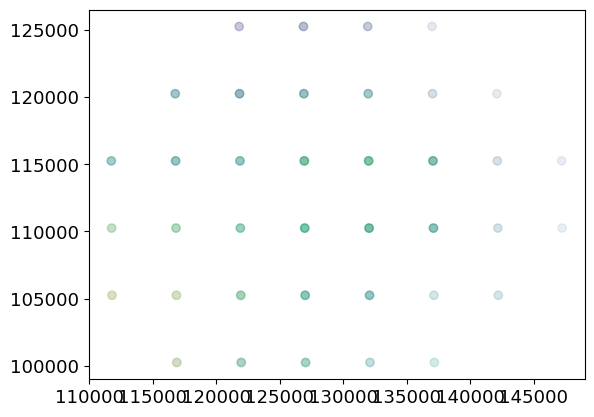

In [21]:
plt.scatter(xs[kind==11], ys[kind==11], c=value[kind==11], alpha=0.1)

In [18]:
mask = outlier <= 3

np.unique(kind[mask])

array([12, 14])

In [36]:
def get_departures(state, obs_include, analysis_time):

    ob_f = pd.read_csv(obs_file)
    # read from history files
    Hxfm = np.empty((0,state.ne))  # need to init this here cause need size of ensemble
    # if you want only a subset of observations, this will do that. Make sure to add additional options as the file contains more data
    if len(obs_include) > 0:
        include = []
        for ob in obs_include:
          if ob == "DBZ0":
             include.append(13)
          if ob == "DBZ":
             include.append(12)
          if ob == 'VR':
             include.append(11)
    ob_f = ob_f[ob_f['kind'].isin(include)]
    
    #set spatial and temporal conditions to index the observation data 
    g_lat_max = state.late[:].max()
    g_lat_min = state.late[:].min()
    g_lon_max = state.lone[:].max()
    g_lon_min = state.lone[:].min()
    g_alt_max = max(state.zc.data[:]) + state.hgt
    g_alt_min = min(state.zc.data[:]) + state.hgt
    
    dtime  = dt.timedelta(0,int(window/2))
    begin  = cftime.date2num(analysis_time - dtime, sec_utime)
    ending = cftime.date2num(analysis_time + dtime, sec_utime)
    
    data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
              (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
              (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)
    
    subdata = ob_f[data_mask]
    idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
                                                                   subdata['kind'].values, 
                                                                   subdata['lat'].values,                                         
                                                                   subdata['lon'].values,
                                                                   subdata['height'].values,
                                                                   subdata['elevation'].values,
                                                                   subdata['azimuth'].values)

    value   = np.empty((0))
    value   = np.append(value,   subdata['value'].values[idx])
    dep = value[:, np.newaxis] - Hxf
    return dep

In [38]:
start = dt.datetime(2024,5,8,20)
end = dt.datetime(2024,5,8,21)
tdel = dt.timedelta(minutes=5)

for time in np.arange(start, end+tdel, tdel):
    analysis_time = time.astype(dt.datetime)
    myDTstring = analysis_time.strftime("%Y,%m,%d,%H,%M,%S")

    with open(f'{fpath}{name}.exp', 'rb') as f:
        exper = json.load(f)
    files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

    state = ens.read_CM1_ens(files, exper, state_vector=state_vector.Hxf, DateTime=analysis_time)   
    ens.ens_CM1_C2A(state)
    ens.ens_CM1_coords(state)
    
    obs_file = exper['radar_obs']
    window = int(exper['DA_PARAMS']['assim_window'])
    
    obs_error = exper['DA_PARAMS']['obs_errors']
    outlier = exper['DA_PARAMS']['outlier']

    dep = get_departures(state, ['DBZ0'], analysis_time)

    if analysis_time == start:
        full = dep.copy()
    else:
        full = np.concat([full, dep], axis=0)

    del state
        


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 2700 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/test/member001/cm1rst_000003.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:00:00 


 Wallclock time for serial read netCDF ensemble files: 2.113  sec

 Wallclock time to convert from C to A grid: 0.436  sec

 Wallclock time to read arrays from netCDF ensemble files: 2.694  sec

 Wallclock time to convert from C to A grid: 0.436  sec

 Wallclock time to create coordinates: 0.0  sec
 calcHx:  OBS   LAT MIN/MAX:   33.618283845221214 36.99285857702675
 calcHx:  MODEL LAT MIN/MAX:   33.62953247125773 37.058100351453895
 calcHx:  OBS   LON MIN/MAX:   -99.44232358785833 -95.31078620011496
 calcHx:  MODEL LON MIN/MAX:   -99.42855179656584 -95.2309098106186
 calcHx:  OBS   HGT MIN/MAX:   144.60763863317047 43511.96395013844
 calcHx:  MODEL HGT MIN/MAX:   75.0 19700.0

 ==> Fin

In [28]:
new = np.concat([dep, dep2], axis=0)

In [48]:
np.shape(full)

(67048, 36)

In [49]:
len(full.flatten())

2413728

In [47]:
counts

array([    2,     8,    13,    10,     3,     0,     0,     1,     4,
           9,    14,    10,     4,    21,    65,    90,   126,   130,
         220,   423,   785,  1526,  2669,  4313,  7050, 10473])

27969
27969


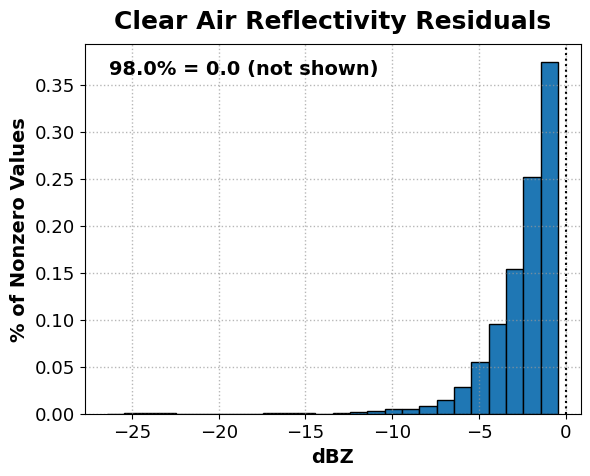

In [66]:
eqzero = 100*list(full.flatten()).count(0.0)/len(full.flatten())
bins = np.arange(np.min(full), 0, 1)
counts, bin_edges  = np.histogram(full.flatten(), bins=bins)
#ncounts, nbin_edges  = np.histogram(full.flatten(), bins=bins)

print(sum(counts))
print(sum(ncounts))

bin_c= (bin_edges[:-1] + bin_edges[1:]) / 2
nbin_c = (nbin_edges[:-1] + nbin_edges[1:]) / 2

fig=plt.figure()
plt.title('Clear Air Reflectivity Residuals', weight='bold', y=1.02)
plt.bar(bin_c, counts/sum(counts), width=1, edgecolor='k')

plt.text(0.05, .96, f"{eqzero:.1f}% = 0.0 (not shown)",va='top', fontsize=14, weight='bold', transform=plt.gca().transAxes)

plt.xlabel('dBZ')
plt.ylabel('% of Nonzero Values')
plt.axvline(0, color='k', ls=':')
plt.grid(ls=":", alpha=0.7)

In [15]:

myDTstring = '2024,05,08,19,15,00'

with open('/work/jessica.mcdonald/CM1_LETKF_2025/AllExperiments/DBZ/DBZ.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 19:15:00

 ==> FindRestartFile:  Found time 0 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/AllExperiments/DBZ/member001/cm1rst_000000.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 19:15:00 


 Wallclock time for serial read netCDF ensemble files: 19.147  sec

 Wallclock time to convert from C to A grid: 0.915  sec

 Wallclock time to create ensemble means: 1.321  sec

 Wallclock time to read arrays from netCDF ensemble files: 22.163  sec

 Wallclock time to create coordinates: 0.0  sec


(80000.0, 250000.0)

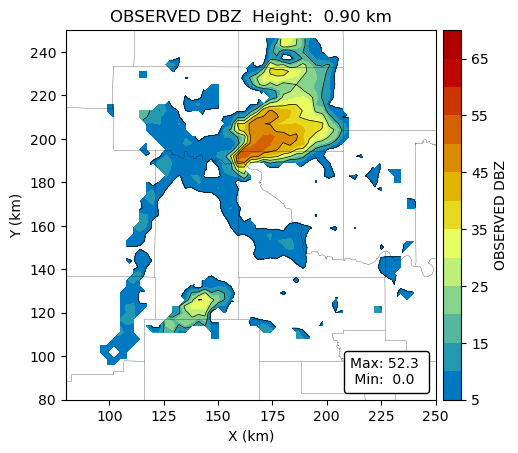

In [25]:
fig,ax=plt.subplots(1)
mfld = N.ma.masked_less_equal(f3d[5,:,:], 0.0)
label = "OBSERVED DBZ"
PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[5], label = label, ax = ax, \
       counties=True, cmap=ctables.REF_default, zoom = zoom)
ax.set_xlim(80*1000, 250*1000)
ax.set_ylim(80*1000, 250*1000)

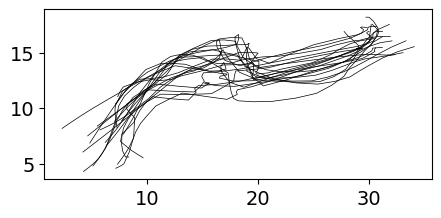

In [16]:
t=10
fig=plt.figure(figsize=(5,5))
ax = plt.gca()
ax.set_aspect('equal')
for mem in np.arange(1,21,1):
    #try:
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{mem:03d}/cm1rst_{t:06d}.nc',decode_timedelta= True)
   
    
    ax.plot(cm1.ua[0,:30,0,-1],cm1.va[0,:30,0,-1],lw=0.5, color='k' )
    #ax.plot(cm1.theta[0,:30,0,-1],cm1.zh[:30],lw=0.5, color='k' )
    cm1.close()
    

# modifying warm bubble code

In [12]:
#import datetime as dt

import sys
sys.path.append('src/') 

import cftime 
from datetime import datetime as py_datetime

import time
import datetime
from datetime import datetime as py_datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import ens

# from contextlib import redirect_stdout
# import io
def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime
from subprocess import *
#from cbook2 import *
import plot_src.ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap

sys.path.append('src/fsrc/') 
from fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state

from ens import read_CM1_ens

def fnormal(prng=N.random, scale=1.0, size=(1,)):
  return prng.normal(scale=scale, size=size)

def funiform(prng=N.random, scale=1.0, size=(1,)):
    return scale*(0.5 - prng.uniform(size=size))

In [ ]:
work/jessica.mcdonald/CM1_LETKF_2025/experiments/shiftCooked_CM1/shiftCooked_CM1.exp

In [282]:
#experiment = 'AllExperiments/DBZ'
myDTstring = '2024,05,08,19,30,00'

with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/shiftCooked_CM1/shiftCooked_CM1.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False)#,prior=True)

ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 19:30:00

 ==> FindRestartFile:  Found time 0 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/shiftCooked_CM1/member001/cm1rst_000000.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 19:30:00 


 Wallclock time for serial read netCDF ensemble files: 4.414  sec

 Wallclock time to convert from C to A grid: 0.664  sec

 Wallclock time to create ensemble means: 1.247  sec

 Wallclock time to read arrays from netCDF ensemble files: 7.07  sec

 Wallclock time to create coordinates: 0.0  sec


In [89]:
centerx + (xypert[:,0,n]*max_x_offset)

array([ 87879.05893411,  92250.62123029, 103270.5476856 ])

In [92]:
xypert[0,0,n]*max_x_offset*2

np.float64(-24241.882131789396)

In [51]:
#def ens_IC_warm_bubble(ens_state, plot=False, writeout=False):

# These values are set in the experiment dictionary created at the begining of the run

nb           = ens_state.experiment['INIT']['nb']
wpert        = ens_state.experiment['INIT']['wpert']
upert        = ens_state.experiment['INIT']['upert']
vpert        = ens_state.experiment['INIT']['vpert']
tpert        = ens_state.experiment['INIT']['tpert'] 
tdpert       = ens_state.experiment['INIT']['tdpert']
qvpert       = ens_state.experiment['INIT']['qvpert']
centerx      = ens_state.experiment['INIT']['centerx']
centery      = ens_state.experiment['INIT']['centery']
max_x_offset = ens_state.experiment['INIT']['max_x_offset']
max_y_offset =ens_state.experiment['INIT']['max_y_offset']
zbmin        = ens_state.experiment['INIT']['zbmin']
zbmax        = ens_state.experiment['INIT']['zbmax']
bhrad        = ens_state.experiment['INIT']['rbubh']
bvrad        = ens_state.experiment['INIT']['rbubv']
r_seed       = ens_state.experiment['INIT']['r_seed']

print(upert, wpert, vpert, tpert, tdpert)

klevel      = 4   # level to plot perturbations
me          = int(ens_state.ne/2)  # which member to plot

np.random.seed(r_seed)
xypert = (np.random.rand(nb,2,ens_state.ne)*2)-1

# calculate additional random modifications to T and W, up to 75% the size of the prescribed perturbation   
t_adjust = (xypert[0][0])
rand_t = (tpert*.50) * t_adjust

for n in np.arange(ens_state.ne):

    # additional edit - add the first x and y perturbations, but halved, to ALL bubbles
    xshift = xypert[0,0,n]*max_x_offset*1.5 
    yshift = xypert[0,1,n]*max_y_offset*1.5

    xb = centerx + (xypert[:,0,n]*max_x_offset) + xshift # these are length nb
    yb = centery + (xypert[:,1,n]*max_y_offset) + yshift
    zb = zbmax*np.ones(xb.shape) + ens_state.hgt
    
    ni, nj, nk = ens_state['nx'],ens_state['ny'],ens_state['nz']
    xh= np.tile(ens_state['xc'][:], (nj*nk,1)).reshape(nk, nj, ni)
    yh= np.tile(ens_state['yc'][:], (ni*nk,1)).reshape(nk, nj, ni).swapaxes(1,2) 
    zh= ens_state['zc'][:, np.newaxis, np.newaxis]
    
    pert = np.zeros([nk,nj,ni])
    
    for b in range(nb): # this uses the equation from CM1 to create the warm bubbles
        beta = np.sqrt( ((xh- xb[b])/bhrad)**2 + ((yh- yb[b])/bhrad)**2 + ((zh - zb[b])/bvrad)**2 )
        mask = beta < 1
        pert[mask]+= (np.cos(0.5*np.pi*beta[mask])**2)
    
    pospert = (pert - pert.min()) / (pert.max()-pert.min())
    neupert = 0.5 - pospert
  
    print(f'\n ==> ens_IC_warm_bubble: ens member {n+1} max T perturbation = {tpert+rand_t[n]} ')
    
    if tpert > 0.0:
        ens_state['TH'][n]  = ens_state['TH'][n]*0
        ens_state['TH'][n] = ens_state['TH'][n] + (tpert+rand_t[n])*pospert
    if wpert > 0.0:
        ens_state['W'][n]  = ens_state['W'][n]  + wpert*pospert        
    if upert > 0.0:
        ens_state['U'][n]  = ens_state['U'][n]  + upert*neupert
    if vpert > 0.0:
        ens_state['V'][n]  = ens_state['V'][n]  + vpert*neupert

    if tdpert > 0.0 and qvpert < 0.01:                                  # Dont do both, prefer saturations...
        p0 = 1000.*(ens_state['PI0'][n])**3.508
        e  = ens_state['QV'][n]*p0/(0.622+ens_state['QV'][n])                       # vapor pressure
        e  = np.clip(e, 0.001, 100.)                                     # avoid problems near zero
        td = 273.16 + ( 243.5 / ( 17.67/np.log(e/6.112) - 1.0 ) )        # Bolton's approximation
        td = np.clip(td + tdpert*pospert, 200.0, (p0*ens_state['TH'][n])-0.1)  # make sure Td is < T
        
        # Transform back
        tdc = td - 273.16
        e   = 6.112 * np.exp(17.67*tdc / (tdc+243.5) )                   # Bolton's approximation
        ens_state['QV'][n] = 0.622*e / (p0-e)
  
  # If qvpert > 0, essentially saturate the regions where the warm bubbles are.
    if qvpert > 0.0:
        tc = (ens_state['PI0'][n]*ens_state['TH'][n]) - 273.16
        p0 = 1000.*(ens_state['PI0'][n])**3.508
        e  = 6.112 * np.exp(17.67*tc / (tc+243.5) )  
        qvs = (0.622*e)/ (p0-e)      
        ens_state['QV'][n] = np.where(pospert > 0.0, (100.-qvpert)*qvs/100., ens_state['QV'][n])

# Write ensemble back out
  # if writeout:
  #   write_CM1_ens(ens_state, writeEns=True, writeFcstMean=True, overwrite=True)

0.0 1.0 0.0 3.0 0.0

 ==> ens_IC_warm_bubble: ens member 1 max T perturbation = 4.405524803393642 

 ==> ens_IC_warm_bubble: ens member 2 max T perturbation = 1.55218064994159 


/tmp/ipykernel_3377924/3649726524.py:87: RuntimeWarning: overflow encountered in exp
  e  = 6.112 * np.exp(17.67*tc / (tc+243.5) )
/tmp/ipykernel_3377924/3649726524.py:88: RuntimeWarning: invalid value encountered in divide
  qvs = (0.622*e)/ (p0-e)



 ==> ens_IC_warm_bubble: ens member 3 max T perturbation = 1.6483224041545919 

 ==> ens_IC_warm_bubble: ens member 4 max T perturbation = 2.734377811154903 

 ==> ens_IC_warm_bubble: ens member 5 max T perturbation = 1.6177620988352572 

 ==> ens_IC_warm_bubble: ens member 6 max T perturbation = 4.069613281843292 

 ==> ens_IC_warm_bubble: ens member 7 max T perturbation = 2.5064319684011824 

 ==> ens_IC_warm_bubble: ens member 8 max T perturbation = 3.7020259162773232 

 ==> ens_IC_warm_bubble: ens member 9 max T perturbation = 3.206024442203472 

 ==> ens_IC_warm_bubble: ens member 10 max T perturbation = 3.8191178260748577 

 ==> ens_IC_warm_bubble: ens member 11 max T perturbation = 4.1385713224575715 

 ==> ens_IC_warm_bubble: ens member 12 max T perturbation = 2.6885591671235645 

 ==> ens_IC_warm_bubble: ens member 13 max T perturbation = 2.5075659979560685 

 ==> ens_IC_warm_bubble: ens member 14 max T perturbation = 2.9690767955870876 

 ==> ens_IC_warm_bubble: ens member 1

In [16]:
import colormaps as cmaps
import plot_src.ctables as ctables

#centerx      = ens_state.experiment['INIT']['centerx']
#centery      = ens_state.experiment['INIT']['centery']


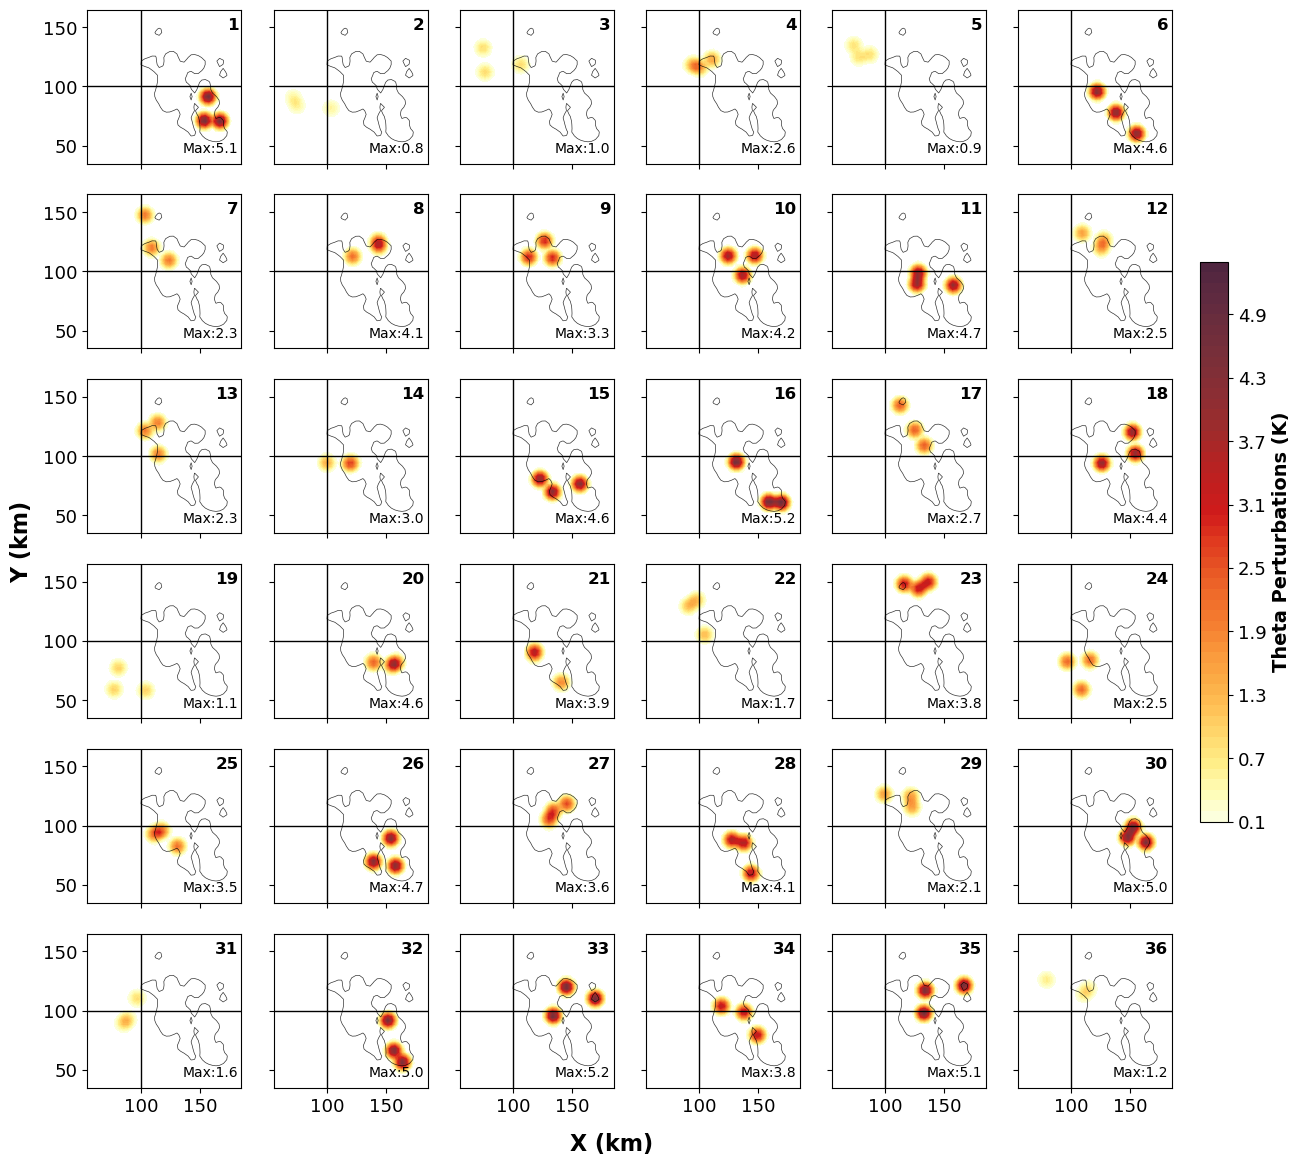

In [59]:


ne = ens_state.ne
height = 1 # in km
cref = True
obs = True
plot_width = 130 # in km 
smooth_obs = True

x = ens_state.xc[:]/1000
y = ens_state.yc[:]/1000
z = ens_state.zc[:]/1000

zi = findnearest(z, height) # if cref is chosen, this isn't used
# prepping the observations

fig,axes = plt.subplots(6,6, figsize=(14,14), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

thp = ens_state['TH'][:] -ens_state['TH'][:,:,-1,0][:,:,np.newaxis, np.newaxis]
w = ens_state['W'][:]#

full_field= (thp).sum(axis=(0,1))
yc, xc = np.where(full_field == full_field.max())

yc,xc = centery/1000, centerx/1000

if plot_width!= None:
    # axes[0,0].set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) # shift plot 20 km to the right, it just looks better
    # axes[0,0].set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)

    axes[0,0].set_xlim(xc-plot_width/2, xc+plot_width/2) # shift plot 20 km to the right, it just looks better
    axes[0,0].set_ylim(yc-plot_width/2, yc+plot_width/2)


xx,yy = np.meshgrid(x,y)
for i,ax in enumerate(axes.flatten()):
     # -1 is the mean member, so always skip it

    

    im=ax.contourf(x,y, thp[i,zi,:,:],cmap=cmaps.redy3,levels=np.arange(.1, 5.5, .1))    
    ax.contour(x,y, thp[-1,zi,:,:], levels=np.arange(.1, 5.1, .5), colors='k', linewidths=0.5, alpha=0.8)

    #ax.contour(x,y, w[i, zi], levels=[0,.5, 1, 1.5, 2], linewidths=1, colors='b')

    #ax.scatter(xx.flatten(), yy.flatten(), s=0.5, color='k', alpha=0.2)

    ax.axhline(100, color='k', lw=1)
    ax.axvline(100, color='k', lw=1)

    
    
    ax.text(0.98, .05, f'Max:{thp[i].max():.1f}', va='bottom',ha='right', fontsize=10, transform=ax.transAxes)
    ax.text(0.98, .95, f'{i+1}', ha='right', va='top',fontsize=12, transform=ax.transAxes, weight='bold')

# xwidth = (axes[0,0].get_position().x1-axes[0,0].get_position().x0)*.2
# ywidth = (axes[0,0].get_position().y1-axes[0,0].get_position().y0)*.4
# plt.subplots_adjust(hspace = ywidth, wspace = ywidth)

cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Theta Perturbations (K)', weight='bold')

#plt.tight_layout()

fig.text(0.5, 0.07, 'X (km)', ha='center', va='center', weight='bold', fontsize=16);
fig.text(0.07,0.5, r'Y (km)', weight='bold', va='center', fontsize=16, rotation='vertical');

[31] [43]


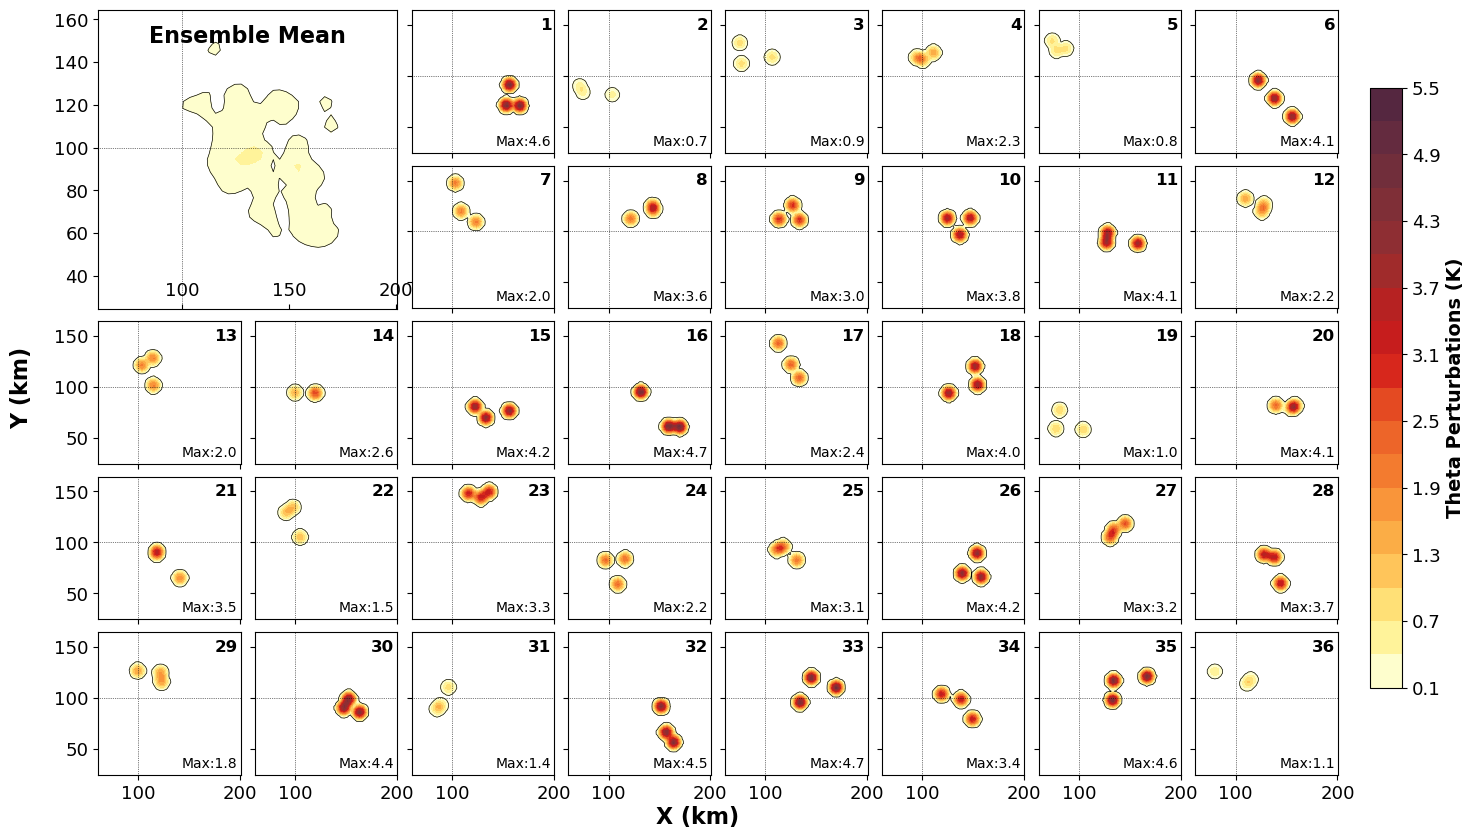

In [283]:

ne = ens_state.ne
height = 1 # in km
#cref = True
#obs = True
plot_width = 140#220 # in km 


thp = ens_state['TH'][:] -ens_state['TH'][:,:,-1,0][:,:,np.newaxis, np.newaxis]


fig, axes = plt.subplots(5,8, sharex=True, sharey=True, figsize=(16,10), subplot_kw={'aspect':'equal'})
gs = axes[0,1].get_gridspec()
for ax in [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]:
    ax.remove()

axbig = fig.add_subplot(gs[0:2, 0:2])
axbig.set_aspect('equal')
axbig.tick_params(axis="x", direction="in", pad=-20)

ax_list = []# axes.flatten
for n,ax in enumerate(axes.flatten()):
    if n not in [0,1,8,9]:
        ax_list.append(ax)


x = ens_state.xc[:]/1000
y = ens_state.yc[:]/1000
z = ens_state.zc[:]/1000

zi = findnearest(z, height) # if cref is chosen, this isn't used

mean_field = thp[-1, zi]
smth = gaussian_filter(mean_field, sigma=3)
yc, xc = np.where(smth == smth.max())



# now shift 
# shift = 0 #km
#xc = xc[0] - int(20/(ens_state.dx/1000))
#yc = yc[0] + int(25/(ens_state.dy/1000))


axbig.scatter(x[xc],y[yc])

print(yc, xc)

if plot_width!= None:
    axes[-1,-1].set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) # shift plot 20 km to the right, it just looks better
    axes[-1,-1].set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)
axbig.set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) 
axbig.set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)


### obs
axbig.contourf(x,y,mean_field, cmap=cmaps.redy3,levels=np.arange(.1, 5.5, .3))
axbig.contour(x,y, mean_field, colors='k', linewidths=0.5, levels=np.arange(.1, 5.5, 5))
axbig.text(0.5, .95, 'Ensemble Mean', ha='center', va='top', fontsize=16, weight='bold', transform=axbig.transAxes)

axbig.axhline(100, color='k', lw=.5, ls=':')
axbig.axvline(100, color='k', lw=.5, ls=':')



for i,ax in enumerate(ax_list):

    
    im=ax.contourf(x,y,thp[i,zi,:,:],cmap=cmaps.redy3,levels=np.arange(.1, 5.5, .3)) 
    #ax.contourf(x,y, dbz, colors=['C0'], levels=[5,100]) 
    ax.contour(x,y, thp[i,zi,:,:], colors='k', levels=np.arange(.1, 5.5, 5), linewidths=0.5)
    ax.text(0.98, .03, f'Max:{thp[i,zi,:,:].max():.1f}', va='bottom',ha='right', fontsize=10, transform=ax.transAxes)
    ax.text(0.98, .95, f'{i+1}', ha='right', va='top',fontsize=12, transform=ax.transAxes, weight='bold')

    ax.axhline(100, color='k', lw=.5, ls=':')
    ax.axvline(100, color='k', lw=.5, ls=':')

plt.subplots_adjust(hspace = .05 ,wspace = .1)

cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Theta Perturbations (K)', weight='bold')


fig.text(0.5, 0.07, 'X (km)', ha='center', va='center', weight='bold', fontsize=16);
fig.text(0.07,0.5, r'Y (km)', weight='bold', va='center', fontsize=16, rotation='vertical');


# ComputeHx tests - reading in and processing obs

In [1]:
import sys

sys.path.append('src/')
import os
import numpy as N
import math as M
import datetime as DT 
from netCDF4 import *
import pyDart
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import json
import src.plot_src.ctables as ctables


from pyDart import dxy_2_dll
import pandas as pd
import pickle
import numpy as np
import cftime


day_utime   = "days since 1601-01-01 00:00:00"#utime("days since 1601-01-01 00:00:00") JEDIT
sec_utime   = "seconds since 1970-01-01 00:00:00"#utime("seconds since 1970-01-01 00:00:00") JEDIT

truelat1, truelat2 = 30.0, 60.0
map_projection='lcc'

# myDTstring = '2024,05,08,20,00,00,00'
# time = [2024,5,8,20,00,0]
# analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))

# with open('/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/DBZ_VR.exp', 'rb') as f:
#     exper = json.load(f)
# files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)


fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w/'
name = fpath.split('/')[-2]
myDTstring = '2024,05,08,20,00,00'
time = [2024,5,8,20,00,0]
analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))

with open(f'{fpath}{name}.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

# ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
# ens.ens_CM1_coords(ens_state)

state = ens.read_CM1_ens(files, exper, state_vector=state.Hxf, DateTime=analysis_time)   
ens.ens_CM1_C2A(state)
ens.ens_CM1_coords(state)

obs_file = exper['radar_obs']
window = int(exper['DA_PARAMS']['assim_window'])

obs_error = exper['DA_PARAMS']['obs_errors']
outlier = exper['DA_PARAMS']['outlier']


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 1200 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w/member001/cm1rst_000002.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:00:00 


 Wallclock time for serial read netCDF ensemble files: 13.115  sec

 Wallclock time to convert from C to A grid: 0.441  sec

 Wallclock time to read arrays from netCDF ensemble files: 13.702  sec

 Wallclock time to convert from C to A grid: 0.442  sec

 Wallclock time to create coordinates: 0.0  sec


In [3]:
obs_error

{'11': ['VR', 3], '12': ['DBZ', 7], '13': ['DBZ0', 5]}

In [ ]:
python /work/jessica.mcdonald/CM1_LETKF_2025/run_filter.py --exper RUN_LETKF/RUN_LETKF.exp -t 2003,05,08,21,40,00 --freq -300

In [8]:
window=15
#obs_file = 'Obs/8may24_cm1_obs.csv'
#obs_file = 'Obs/obs_seq_8may03_2km.h5'
init=False

In [3]:
path = exper['base_dir']

In [2]:
ob_f = pd.read_csv(obs_file)
np.unique(ob_f.kind)

array([11, 12, 13])

In [4]:
obs_include = ['VR', 'DBZ',  'DBZ0_W']

In [14]:
ob_f

,level_0,azimuth,date,days,elevation,error_var,height,index,kind,lat,lon,seconds,utime,value,x,y,z
0,0,-126.831521,2024-05-08 19:45:00,9167716250,0.5,0,980.866683,0,11,34.698148,-97.954970,71100,1715197500,-13.534043,-59750.0,-44750.0,980.866683
1,1,-123.634709,2024-05-08 19:45:00,9167716250,0.5,0,930.822765,1,11,34.698148,-97.899883,71100,1715197500,-16.513900,-59750.0,-39750.0,930.822765
2,2,-120.181853,2024-05-08 19:45:00,9167716250,0.5,0,885.831895,2,11,34.698148,-97.844796,71100,1715197500,-17.446597,-59750.0,-34750.0,885.831895
3,3,-116.469078,2024-05-08 19:45:00,9167716250,0.5,0,846.144220,3,11,34.698148,-97.789709,71100,1715197500,-12.875253,-59750.0,-29750.0,846.144220
4,4,-112.500605,2024-05-08 19:45:00,9167716250,0.5,0,812.019010,4,11,34.698148,-97.734621,71100,1715197500,-12.601407,-59750.0,-24750.0,812.019010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266171,1266171,55.289590,2024-05-08 21:51:00,9167716250,8.0,0,36859.438306,1266171,14,36.992859,-95.971832,78660,1715205060,0.000000,195250.0,135250.0,36859.438306
1266172,1266172,52.420773,2024-05-08 21:51:00,9167716250,8.0,0,38367.976887,1266172,14,36.992859,-95.806571,78660,1715205060,0.000000,195250.0,150250.0,38367.976887
1266173,1266173,49.757065,2024-05-08 21:51:00,9167716250,8.0,0,39985.143531,1266173,14,36.992859,-95.641309,78660,1715205060,0.000000,195250.0,165250.0,39985.143531
1266174,1266174,47.287563,2024-05-08 21:51:00,9167716250,8.0,0,41702.388740,1266174,14,36.992859,-95.476048,78660,1715205060,0.000000,195250.0,180250.0,41702.388740


In [15]:
np.unique(ob_f.kind)

array([11, 12, 14])

In [11]:
if ('DBZ0' in obs_include) & ('DBZ0_W' in obs_include):
    print("**** ATTENTION ****")
    print('BOTH DBZ0 (clear air) AND DBZ0_W (treats clear air like w=0) ARE INCLUDED OBSERVATION TYPES')

h


In [13]:
if 'DBZ0_W' in obs_include:
    ob_f.loc[ob_f.kind==13, 'kind'] = 14

In [11]:
%%time
yes=True
final=True

outlier = exper['DA_PARAMS']['outlier']


if yes==True:
    ob_f = pd.read_csv(obs_file)
  
# Initialize a bunch of containers, they get converted to numpy arrays below

    lat     = N.empty((0))
    lon     = N.empty((0))
    dates   = N.empty((0))
    value   = N.empty((0))
    kind    = N.empty((0))
    height  = N.empty((0))
    elev    = N.empty((0))
    az      = N.empty((0))
    err_var = N.empty((0))
    idx     = N.empty((0))
    
    analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
     
    print("\n --> ComputeHx:  Reading in model state for HxF at %s \n" %  (analysis_time.strftime("%Y-%m-%d %H:%M:%S")))
    
    Hxfm = N.empty((0,state.ne))  # need to init this here cause need size of ensemble


    if len(obs_include) > 0:
        include = []
        for ob in obs_include:
            
            if ob == "DBZ0_W":
                include.append(14)
                ob_f.loc[ob_f.kind==13, 'kind'] = 14 # recode all clear air obs to be vertical velocity
                 
            if ob == "DBZ0":
                include.append(13)
            if ob == "DBZ":
                include.append(12)
            if ob == 'VR':
                include.append(11)

        ob_f = ob_f[ob_f['kind'].isin(include)]

  #set spatial and temporal conditions to index the observation data 
    g_lat_max = state.late[:].max()
    g_lat_min = state.late[:].min()
    g_lon_max = state.lone[:].max()
    g_lon_min = state.lone[:].min()
    g_alt_max = max(state.zc.data[:]) + state.hgt
    g_alt_min = min(state.zc.data[:]) + state.hgt
    
    dt     = DT.timedelta(0,int(window/2))
    begin  = cftime.date2num(analysis_time - dt, sec_utime)
    ending = cftime.date2num(analysis_time + dt, sec_utime)
    
    data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
              (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
              (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)
    
    subdata = ob_f[data_mask]
    
    
    if len(subdata.index) > 0:
        print("\n --> ComputeHx:  Total number of obs found at search time: %s \n" % len(subdata.index))
    else:
        print("\n --> ComputeHx:  No obs found at search time:  %s exiting......\n" % (analysis_time))
        sys.exit(0)

# Compute Hxfs from 

    idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
                                                               subdata['kind'].values, 
                                                               subdata['lat'].values,                                         
                                                               subdata['lon'].values,
                                                               subdata['height'].values,
                                                               subdata['elevation'].values,
                                                               subdata['azimuth'].values)
   
#At this point we have created all the Hxfs and so we can make sure we have enough obs to run
    if idx != None:
        nobs = N.size(idx) 

    print("\n --> ComputeHx:  Total number of obs found is: %d \n" % (nobs))

# # retrieve these from pyTable

#     err_var = N.append(err_var, subdata['error_var'].values[idx])   
#     value   = N.append(value,   subdata['value'].values[idx])
#     dates   = N.append(dates,   subdata['date'].values[idx])
  
#   else:
#     print("\n  >======================================================================<\n")   
#     print("\n    ComputeHx: NOBS == 0:  NO HXF's were created - EXITING computeHx!!!  ")
#     print("\n    ComputeHx:  NOBS == 0:  NO HXF's were created - EXITING computeHx!!! ")
#     print("\n  >======================================================================<\n"   )
#     sys.exit(0)
    
# # Overide the file observation std deviations with either defaults at top of script or input parameters

#   for key in obs_error.keys():
#     print_once = True
#     for n, item in enumerate(kind):
#       if int(item) == int(key):
#          err_var[n] = obs_error[key][1]**2.0
#          if print_once:
#            print("\n --> ComputeHx:  Changing %s observational error to:  %s" % (obs_error[key][0],obs_error[key][1]))
#            print_once = False

# # Here we choose to create a coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# # The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid

#   xs, ys = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
#   zs     = height
  
#   Hxfbar = N.average(Hxf,axis=1)
    
# # We dont use this flag (is supposed to be a flag to tell one whether the obs is used for verification or assimilation, or thrown out)
#   status = N.ones(nobs)

#   if init:
#     create_prior_file(state.ne)
# 
  # write_prior(state.ne, kind, value, dates, err_var, xs, ys, zs, Hxf, Hxfbar, lat, lon, elev, azimuth, status, outlier)
  
  # if final:
  #   newPriorFile = os.path.join(path, "Prior_%s.nc" % analysis_time.strftime("%Y-%m-%d_%H:%M:%S"))
  #   os.rename("Prior.nc", newPriorFile)
  
# timeHxF.stop()
  
 # timeIO.printit("--> ComputeHx:  Total time for ensemble I/O")
  
 # timeHxF.printit("--> ComputeHx:  Time for searching ob table and computing priors")

 # timeMain.stop()
 #  timeMain.printit("--> ComputeHx:  Total time in minutes")

# Print out Wallclock time for ComputeHx

#   now = DT.datetime.now()

#   print("\n  ----------------------------------------------------------------------")
#   print("\n                END PROGRAM ComputeHx                                   ")
#   print("\n      WALLCLOCK END TIME:  %s " % now.strftime("%Y-%m-%d %H:%M")     )
#   print("\n  ----------------------------------------------------------------------\n")
    
# path = exper['base_path']
  
# file_DT = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))

# newPriorFile = os.path.join(path, "Prior_%s.nc" % file_DT.strftime("%Y-%m-%d_%H:%M:%S"))

# os.rename("Prior.nc", newPriorFile)

# print("\n  --> Moved Prior.nc file to %s\n" % (newPriorFile))  


 --> ComputeHx:  Reading in model state for HxF at 2024-05-08 20:00:00 


 --> ComputeHx:  Total number of obs found at search time: 6836 

 calcHx:  OBS   LAT MIN/MAX:   33.618283845221214 36.99285857702675
 calcHx:  MODEL LAT MIN/MAX:   33.62953247125773 37.058100351453895
 calcHx:  OBS   LON MIN/MAX:   -99.44232358785833 -95.31078620011496
 calcHx:  MODEL LON MIN/MAX:   -99.42855179656584 -95.2309098106186
 calcHx:  OBS   HGT MIN/MAX:   144.60763863317047 43511.96395013844
 calcHx:  MODEL HGT MIN/MAX:   75.0 19700.0

 --> ComputeHx:  Total number of obs found is: 5532 

CPU times: user 1.27 s, sys: 257 ms, total: 1.53 s
Wall time: 1.52 s


In [12]:
np.unique(kind)

array([11, 12, 14])

In [24]:
Hxf[kind==11]

array([[27.96382333, 28.35779287, 28.73949645, ..., 27.10609915,
        25.76263539, 26.52827302],
       [27.51831178, 27.979901  , 28.19146866, ..., 26.35973702,
        24.54751185, 25.54890341],
       [26.42523786, 27.00064435, 27.07817561, ..., 25.12645461,
        25.15931578, 24.08537442],
       ...,
       [32.91668607, 32.28318464, 35.50250608, ..., 30.57626859,
        30.33519091, 29.89788602],
       [34.8364015 , 34.83720487, 38.0723605 , ..., 34.9918931 ,
        35.18890772, 34.08905462],
       [35.92023797, 36.53856335, 39.81942168, ..., 37.75722243,
        38.03508292, 36.67403568]])

In [19]:
index = (kind ==11)

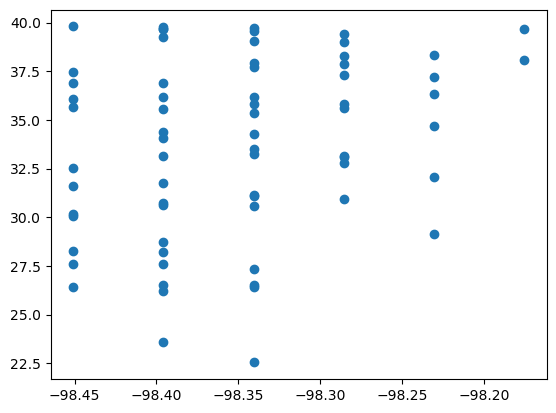

In [23]:
plt.scatter(lon[index], Hxf[index,3])

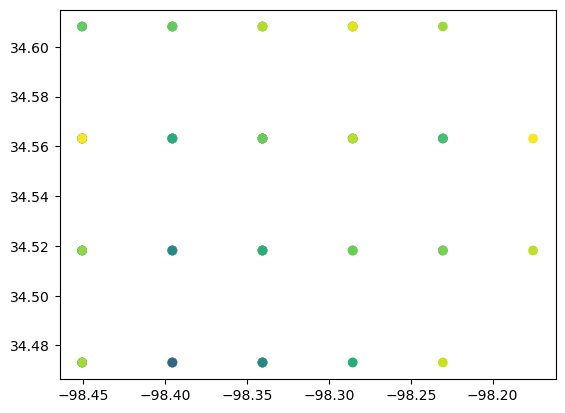

In [20]:
import matplotlib.pyplot as plt
plt.scatter(lon[index][:], lat[index][:],c= Hxf[index][:,3], )

# LETKF

In [9]:
#!/usr/bin/env python
import sys
import os
import numpy as N
import datetime as DT 
from netCDF4 import *
import pyDart
from pyDart import dll_2_dxy
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import pickle
import json
# Fortran functions
sys.path.append( "./fsrc" )
from fpython2 import fstate


In [ ]:
python letkf.py --exper RUN_LETKF/RUN_LETKF.exp --time 2003,05,08,21,00,00 --nthreads 1

In [8]:

#-------------------------------------------------------------------------------
# Default values 

_missing_value = 9900000000.
_time_units    = 'seconds since 1970-01-01 00:00:00'
_calendar      = 'standard'

debug  = False
_update_theta = 1
_variable_dbz_error = False

#-------------------------------------------------------------------------------
# Run parameters for the filter

obs_diag = {11: ["VR"], 12:["DBZ"]}

#-------------------------------------------------------------------------------
def getIndexEqual(field, value):
    return ( field == value )

#-------------------------------------------------------------------------------
def getIndexGT(field, value):
    return ( field > value )

#-------------------------------------------------------------------------------
def getIndexLT(field, value):
    return ( field < value )

########################################################################################################################
#
# Main program
me=True
if me==True:

  stime = timer()
  now = DT.datetime.now()

  print("----------------------------------------------------------------------\n")
  print("              BEGIN PROGRAM LETKF                                     \n ")
  print(("  WALLCLOCK START TIME:  %s \n" % now.strftime("%Y-%m-%d %H:%M")))  
  print("  --------------------------------------------------------------------\n")
  
# Create timers for the code...

  timeFilter   = myTimer(name = "Filter")
  timeIO       = myTimer(name = "I/O")
  timeMain     = myTimer(name = "Program")
  timeHxF      = myTimer(name = "HxF")
  
# Time the data assimilation

  timeMain.start()

#-------------------------------------------------------------------------------
# Parse input command options

#   parser = OptionParser()
#   parser.add_option("-f", "--file",      dest="file",     type="string", help = "Priors netCDF file")
#   parser.add_option("-t", "--time",      dest="time",     type="string", help = "Analysis time in YYYY,MM,DD,HH,MM,SS")
#   parser.add_option("-e", "--exper",     dest="exper",    type="string", help = "experiment run file created to store database info")
#   parser.add_option(      "--nthreads",  dest="nthreads", type="int",    help = "Number of threads for LETKF computation")
#   parser.add_option(      "--outl",      dest="outl",     type="int",    help = "Outlier threshold for observations")
#   parser.add_option(      "--saveW",     dest="saveW",    default=False, help = "Save LETKF weights...", action="store_true")
#   parser.add_option(      "--readW",     dest="readW",    default=False, help = "Read LETKF weights...", action="store_true")
#   parser.add_option(      "--noupdate",  dest="noupdate", default=False, help = "Do not update variables", action="store_true")
#   parser.add_option(      "--aInflate",  dest="ainflate",  type = "int",   help = "Sets type of adaptive inflation (0,1,2,3)", default=None)
#   parser.add_option(      "--HF",        dest="HF",        type = "int",   help = "Sets up writeback skip for HF filter", default=None)
  
#   (options, args) = parser.parse_args()
    
# python letkf.py --exper RUN_LETKF/RUN_LETKF.exp --time 2003,05,08,21,05,00 --nthreads 1  --aInflate 1
#-------------------------------------------------------------------------------  
# Get experiment file
  with open('DBZ_VR/DBZ_VR.exp', 'rb') as p:
        exper = json.load(p)
      
  # if options.exper == None:
  #   print("\n --> LETKF:  No experiment's run filename specified, exiting....\n")
  #   parser.print_help()
  #   sys.exit(-1)
  # else:
  #   with open(options.exper, 'rb') as p:
  #       exper = json.load(p)

#-------------------------------------------------------------------------------
# Get the time stamp
  time = '2024,05,08,20,00,00'.split(",")  
  # if options.time == None:
  #   print("\n --> LETKF:  No analysis time specified, exiting....\n")
  #   parser.print_help()
  #   sys.exit(-1)
  # else:
  #   time = options.time.split(",")
    
#-------------------------------------------------------------------------------
# The rest of the input is options - so set parameters based on what is in the experiment data base

  mpass             = exper['DA_PARAMS']['mpass']
  writeFcstMean     = exper['DA_PARAMS']['writeFcstMean']
  writeAnalMean     = exper['DA_PARAMS']['writeAnalMean']
  saveWeights       = exper['DA_PARAMS']['saveWeights']
  readWeights       = exper['DA_PARAMS']['readWeights']
  rhoriz            = exper['DA_PARAMS']['rhoriz']
  rvert             = exper['DA_PARAMS']['rvert']
  rtime             = exper['DA_PARAMS']['rtime']
  cutoff            = exper['DA_PARAMS']['cutoff']
  zcutoff           = exper['DA_PARAMS']['zcutoff']
  inflate           = exper['DA_PARAMS']['inflate']
  print_state_stats = exper['DA_PARAMS']['print_state_stats']
  path              = exper['base_path']

#-------------------------------------------------------------------------------
# Parallel Threading
  nthreads=8

  # if options.nthreads != None:
  #   nthreads = options.nthreads
  #   print(("\n --> LETKF:  Number of threads requested is from command line:  %d" % nthreads))
  # else:
  #   nthreads = exper['DA_PARAMS']['nthreads']
  #   print(("\n --> LETKF:  Number of threads requested is from EXPER file:  %d" % nthreads))
    

#-------------------------------------------------------------------------------
#  Priors file
  print("\n --> LETKF:  No netCDF Priors file specified, using default priors file")
  ftime      = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  prior_file = os.path.join(path, "Prior_%s.nc" % ftime.strftime("%Y-%m-%d_%H:%M:%S"))
  if os.path.isfile(prior_file):
    print(("\n --> LETKF:  Using prior file:  %s\n" % prior_file))

  # if options.file == None:
  #   print("\n --> LETKF:  No netCDF Priors file specified, using default priors file")
  #   ftime      = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  #   prior_file = os.path.join(path, "Prior_%s.nc" % ftime.strftime("%Y-%m-%d_%H:%M:%S"))
  #   if os.path.isfile(prior_file):
  #     print(("\n --> LETKF:  Using prior file:  %s\n" % prior_file))
  #   else:
  #     print(("\n  --> LETKF:  Could not find prior file:  %s !!!!  Exiting LETKF...." % prior_file))
  #     parser.print_help()
  #     sys.exit(-1)
  # else:
  #   prior_file = options.file

#-------------------------------------------------------------------------------
# Inflation type
  aInflate = 1
  
  inflation_deltaT = exper['DA_PARAMS']['assim_window']
  dt = DT.timedelta(0,inflation_deltaT)
  in_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5])) - dt
  inflate_file = os.path.join(path, "Inflation_%s.nc" % in_time.strftime("%Y-%m-%d_%H:%M:%S"))
  print(("\n --> LETKF:  Trying to find inflation file: %s" % inflate_file))
  inflate_file_exists = False
  if os.path.isfile(inflate_file):
    inflate_file_exists = True
    print(("\n --> LETKF:  Using inflation file: %s" % inflate_file))
      
  # if options.ainflate:
  #   aInflate = options.ainflate
  # else:
  #   aInflate   = exper['DA_PARAMS']['aInflate']
    
  # if aInflate == 0:
  #   inflate_file_exists = False
  # else:
  #   inflation_deltaT = exper['DA_PARAMS']['assim_window']
  #   dt = DT.timedelta(0,inflation_deltaT)
  #   in_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5])) - dt
  #   inflate_file = os.path.join(path, "Inflation_%s.nc" % in_time.strftime("%Y-%m-%d_%H:%M:%S"))
  #   print(("\n --> LETKF:  Trying to find inflation file: %s" % inflate_file))
  #   if os.path.isfile(inflate_file):
  #     inflate_file_exists = True
  #     print(("\n --> LETKF:  Using inflation file: %s" % inflate_file))
  #   else:
  #     inflate_file_exists = False
  #     print("\n --> LETKF:  Could not find inflation file....none will be used.")

#-------------------------------------------------------------------------------
# LETKF Weight I/O flags
  saveWeights = exper['DA_PARAMS']['saveWeights']
  readWeights = exper['DA_PARAMS']['readWeights']
#   if options.saveW:
#     saveWeights = options.saveW
#     print(("\n --> LETKF: saveWeights is from command line:  %s" % saveWeights))
#   else:  
#     saveWeights = exper['DA_PARAMS']['saveWeights']
#     print(("\n --> LETKF: saveWeights is from EXPER file:  %s" % saveWeights))

#   if options.readW:
#     readWeights = options.readW
#     print(("\n --> LETKF: readWeights is from command line:  %s" % readWeights))
#   else:  
#     readWeights = exper['DA_PARAMS']['readWeights']
#     print(("\n --> LETKF: readWeights is from EXPER file:  %s" % readWeights))
   
# #-------------------------------------------------------------------------------
# # Update flag which is useful when debugging (does not overwrite files
  noUpdate = False
#   if options.noupdate:
#       noUpdate = options.noupdate
#       print("\n --> LETKF: noUpdate is set from command line:  No files will be written back")
#   else:
#       noUpdate = False

# #-------------------------------------------------------------------------------
# # outlier threshold
  outlier_threshold = exper['DA_PARAMS']['outlier']
#   if options.outl == None:
#     outlier_threshold = exper['DA_PARAMS']['outlier']
#     print(("\n --> LETKF: obs outlier is from EXPER file:  %d" % outlier_threshold))
#   else:
#     outlier_threshold = options.outl
#     print(("\n --> LETKF: obs outlier is from command line:  %d" % outlier_threshold))

########################################################################################################################
#
# Read in STATE VECTOR for ensemble
  
  timeIO.start()

  analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  
  files, exper = ens.FindRestartFiles(exper, analysis_time, ret_DT=False)
  
  print(("\n  ---->LETKF:  Reading in model state for analysis at %s \n" %  (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
  
  state = ens.read_CM1_ens(files, exper, state_vector = None, DateTime=analysis_time, addmean=1)   
  ens.ens_CM1_coords(state)
  ens.ens_CM1_mean(state)
  
  tanalysis = date2num(analysis_time,units=_time_units,calendar=_calendar)
  
  print(("\n  ---->Analysis state read in for time %s " % (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
  print(("\n  ---->Analysis state universal time %f" % (tanalysis)))

  if debug:
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  No files are written!!!!")
  else:
    if writeFcstMean:
      ens.write_CM1_ens(state, writeFcstMean=writeFcstMean, overwrite=True)
  
  timeIO.stop()
  
########################################################################################################################
#
# Read in observational priors

  timeHxF.start()
  
  analysis_sec = date2num(analysis_time,units=_time_units,calendar=_calendar)
     
  print(("\n  ----> LETKF:  Reading in Prior file:  %s \n" %  (prior_file)))
    
  kind, value, error, lat, lon, xob, yob, zob, tob, Hxf, Hxfbar, outlier = read_prior(analysis_time, file=prior_file, sort=True)

  nobs = Hxf.shape[0]
  ne   = Hxf.shape[1]
  
  if nobs == 0:  
    print(("\n  ----> LETKF:  Prior file is empty, exiting at analysis time %s \n" %  (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
    sys.exit(0)
  else:
    print(("\n  ----> LETKF:  Prior file has %d obs at analysis time %s \n" %  (nobs, analysis_time.strftime("%Y %m-%d %H:%M:%S"))))

    tob = N.array(tob - analysis_sec, dtype=N.float64)   # departure time for temporation localization

    if (outlier_threshold > 0):
      print(('\n  --> LETKF called with an outlier threshold of %d standard deviations' % outlier_threshold))

      mask  = N.where( outlier <= outlier_threshold, True, False )
      mask2 = N.where( kind == 11, True, False )
      print(("Mask before Vr mask:  ", N.count_nonzero(mask)))
      mask  = mask | mask2
      print(("Mask after Vr mask:  ", N.count_nonzero(mask)))

      kind   = kind[mask]
      value  = value[mask]
      error  = error[mask]
      tob    = tob[mask]
      xob    = xob[mask]
      yob    = yob[mask]
      zob    = zob[mask]
      Hxf    = Hxf[mask][:]
      Hxfbar = Hxfbar[mask]
      lat    = lat[mask]
      lon    = lon[mask]

      print('\n  >=====================================================================<')
      print(('\n  --> LETKF:  Number of total    obs = %d' % nobs))
      print(('\n  --> LETKF:  Number of rejected obs = %d' % (nobs - N.count_nonzero(mask) )))
      print(('\n  --> LETKF:  Max outlier: %f  Min outlier:  %f\n' % (outlier.max(), outlier.min())))
    
# Reset number of obs

      nobs = N.count_nonzero(mask)

# Change the dbz error threshold based on each obs innovation mean 

      if _variable_dbz_error:
          mask = N.where( kind == 12, True, False )
          print("  --> LETKF:  Variable dBZ error:  Number of dBZ observations is %d" % N.count_nonzero(mask))
          mask2 = N.where(value > 20., True, False)
          print("  --> LETKF:  Variable dBZ error:  Number of obs where value > 20  %d" % N.count_nonzero(mask2))
          mask  = mask & mask2
          print("  -->  LETKF:  Number of Priors where Obs > 20 and will have their values increased:  %d" % N.count_nonzero(mask))
          Hxfbar[mask] = Hxfbar[mask] + 10.
          Hxf[mask,:] = Hxf[mask,:] + 10.

# Recompute coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid
# Need to do this again because of running-in-place for moving grids...

  xob, yob = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
  dep      = N.zeros(nobs)
  dep[:]   = value[:] - Hxfbar[:]
    
# Here we create the localization arrays

  rdiag    = N.array(error.reshape(nobs,1), order='F')
  rloc     = N.array(N.ones(nobs).reshape(nobs,1), order='F')

# Print some stats...

  print("\n  >==============================================================================================<")
  print(("\n  LETKF:  %s  Total number of observations:  %d" % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"),value.size)))
  print("\n  <==============================================================================================<")
  print("\n  LETKF:  Obs Space Diagnostic for forecast computed via Dowell and Wicker, MWR 2009, Additive Noise\n")
  print("\n  LETKF:  Obs Std  |  Root-Mean-Sq-Error  |    Bias    |  Spread (obsErr^2+Hxf_var^2)  |   Consistency Ratio")
  print("\n  >==============================================================================================<\n")

  for key in list(obs_diag.keys()):
    index_kind  = getIndexEqual(kind, key)
    d           = dep[index_kind]
    
    if obs_diag[key][0] == 'DBZ':

  # Non-zero dBZ obs
  
        index_dbz   = index_kind & getIndexGT(value, 0.1)

        if N.sum(index_dbz) > 0:
          ob_err      = error[index_dbz].mean()
          d           = dep[index_dbz]
          Hxftmp      = Hxf[index_dbz,:]
          Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
          inno_var    = N.mean((d - d.mean())**2)
          consi_ratio = (ob_err + Hxf_var) / inno_var

          print(("\n -->  LETKF:  %s  NOBS: %5.5d  %3.3s>0: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_dbz), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
        else:
          print(("\n -->  LETKF:  %3.3s>0: is not present in observations" % (obs_diag[key][0])))

  # zero dBZ obs      

        index_dbz   = index_kind & getIndexLT(value, 0.1)
        if N.sum(index_dbz) > 0:
          ob_err      = error[index_dbz].mean()
          d           = dep[index_dbz]
          Hxftmp      = Hxf[index_dbz,:]
          Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
          inno_var    = N.mean((d - d.mean())**2)
          consi_ratio = (ob_err + Hxf_var) / inno_var
          print(("\n --> LETKF:%s  NOBS: %5.5d  %3.3s<0: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_dbz), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
        else:
          print(("\n -->  LETKF:  %3.3s<=0: is not present in observations" % (obs_diag[key][0])))

  # other obs

    elif d.size > 0:

      ob_err      = error[index_kind].mean()
      d           = dep[index_kind]
      Hxftmp      = Hxf[index_kind,:]
      Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
      inno_var    = N.mean((d - d.mean())**2)
      consi_ratio = (ob_err + Hxf_var) / inno_var
      print(("\n -->  LETKF:  %s  NOBS: %5.5d    %3.3s: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_kind), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
    else:
      print(("\n -->  LETKF:  %s is not present in observations" % (obs_diag[key][0])))

  print("\n  >============================================================================================<\n")

  timeHxF.stop()
  
#################################################################################################
#
# Adaptive inflation: read in or create dummy file....

  if aInflate == 0:   # just create a dummy array of ones...
    print("\n -->  LETKF:  Adaptive inflation is turned off....\n")
    inflate = N.ones((state.nz, state.ny, state.nx), order='F', dtype=N.float64)
  else:
    print("\n -->  LETKF:  Adaptive inflation is turned on....\n")
    if inflate_file_exists:
      print(("\n -->  LETKF:  Adaptive inflation is using prior file:  %s\n" % inflate_file))
      inflate = read_inflation_file(file=inflate_file)
    else:
      print("\n -->  LETKF: Adaptive inflation cannot find the previous inflation file, initializing inflation array to 1.0 \n") 
      inflate = N.ones((state.nz, state.ny, state.nx), order='F', dtype=N.float64)
      
################################################################################################################################

# Begin LETKF analysis
 
  if print_state_stats: print_state_diagnostics(state, store=True)
  
  print("\n  >=======================  >>BEGIN FILTER<< ===========================================<\n")    

# Call the fortran letkf module

  timeFilter.start()

  if mpass == True:

    print("\n -->  LETKF:  MultiPASS algorithm turned on, assimilating VR THEN DBZ\n")
    for key in list(obs_diag.keys()):

      index_kind  = getIndexEqual(kind, key)
      if obs_diag[key][0] == "DBZ":  
        update_theta = 0
      else:
        update_theta = _update_theta

      if N.sum(index_kind) > 0:
        print(("\n-->  LETKF:  %d observations of %3.3s is now being assimilated!\n" % (N.sum(index_kind), obs_diag[key][0])))
        inflateN = fstate.compute_letkf(xob[index_kind], yob[index_kind], zob[index_kind], tob[index_kind], tanalysis,
                                        value[index_kind], Hxf[index_kind], dep[index_kind], rdiag[index_kind], rloc[index_kind], 
                                        rhoriz, rvert, rtime, nthreads, cutoff, zcutoff, update_theta, aInflate, inflate,
                                        saveWeights, readWeights)
      else:
        print(("\n -->  LETKF:%3.3s: NO OBSERVATIONS FOUND!\n" % (obs_diag[key][0])))

  else:

    print("\n -->  LETKF:ALL OBS TYPES BEING ASSIMULATED SIMULTANEOUSLY: MULTIPASS==False\n")
    update_theta = _update_theta
    inflateN = fstate.compute_letkf(xob, yob, zob, tob, tanalysis,
                                    value, Hxf, dep, rdiag, rloc, 
                                    rhoriz, rvert, rtime, nthreads, cutoff, zcutoff, update_theta, aInflate, inflate,
                                    saveWeights, readWeights)
                           
# # inflateN always has the adaptive inflation field produced by LETKF core. Write it out...

#   if aInflate > 0:
#     print(("\n -->  LETKF:  Adaptive Inflation stats:  Max AI:  %3.1f  Min AI %3.1f  Mean AI: %3.1f  StdDev:  %4.3f\n" % \
#         (inflateN.max(), inflateN.min(), inflateN.mean(), inflateN.std())))

#   InflationFile = write_inflation_file(inflateN,fstate.xc,fstate.yc,fstate.zc,analysis_time)
#   newInflationFile = os.path.join(path, InflationFile)
#   os.rename(InflationFile, newInflationFile)
#   print(("\n -->  LETKF:  Moved %s file to directory %s" %(InflationFile, path)))

# # If saveWeights == True, rename the netCDF4 file dumped out by the fortran code

#   if saveWeights:
#     rename_weight_file(analysis_time)

#   timeFilter.stop()

#   print("\n  >=======================  >>END FILTER<< ===========================================<\n")    

#   if print_state_stats: print_state_diagnostics(state, header=True)   
  
# # Write out model state
  
#   timeIO.start()

# # Write ensemble back out

#   if debug:
#     print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
#     print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
#     print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
#     print("\nWARNING WARNING WARNING:  STATE DATA IS NOT WRITTEN BACK OUT!")
#   elif noUpdate:
#     print("\n -->  LETKF:  NO UPDATE FLAG is TRUE....state data will not be written back out!")
#   else:
#     print("\n -->  LETKF:  state data now written back out!")
#     ens.write_CM1_ens(state, writeEns=True, writeAnalMean=writeAnalMean, overwrite=False)#, HF=options.HF)
  
#   timeIO.stop()
  
# # Print out specific timing information

#   timeHxF.printit("")
#   timeFilter.printit("")
#   timeIO.printit("")
  
#   timeMain.stop()
#   timeMain.printit("")

# # Print out Wallclock time for LETKF

#   now = DT.datetime.now()

#   print("\n  ----------------------------------------------------------------------")
#   print("\n                END PROGRAM LETKF                                        ")
#   print(("\n  WALLCLOCK END TIME:  %s \n" % now.strftime("%Y-%m-%d %H:%M")))  
#   print("\n  -----------------------------------------------------------------------\n")


----------------------------------------------------------------------

              BEGIN PROGRAM LETKF                                     
 
  WALLCLOCK START TIME:  2025-04-03 23:56 

  --------------------------------------------------------------------


 --> LETKF:  No netCDF Priors file specified, using default priors file

 --> LETKF:  Using prior file:  /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:00:00.nc


 --> LETKF:  Trying to find inflation file: /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Inflation_2024-05-08_19:59:30.nc

 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 2700 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/member001/cm1rst_000009.nc

  ---->LETKF:  Reading in model state for analysis at 2024 05-08 20:00:00 


 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_

NameError: name 'fstate' is not defined

In [11]:
index_kind  = getIndexEqual(kind, 11)

In [13]:
value[index_kind]

masked_array(data=[ 4.52374311,  6.01211415,  6.85047665,  8.33634024,
                    4.96774367,  6.07902327,  7.29477135,  9.61311077,
                    9.4009037 , 11.16060393, 11.95807832, 13.06172338,
                    5.3660868 ,  6.68399011,  7.09700164,  8.14800688,
                    3.22938288,  5.61464968,  7.54449034, 10.75111367,
                    8.33284458, 11.25389444, 13.21546589, 16.00014901,
                    7.96150039,  9.69652308, 10.93417463, 12.2930178 ,
                    8.07646047,  9.9114899 , 11.26057194, 12.22568771,
                    7.09905546,  9.02461381, 10.48046281, 11.54426008,
                    5.65622932,  8.03630907,  9.59554331, 11.0089845 ,
                    8.59196898, 10.79744315, 12.43769454, 14.09272416,
                    6.90579599,  9.37691369, 11.72306518, 13.67337322,
                    8.44746829, 10.75824723, 12.28244672, 13.58922844,
                    9.02161934, 11.14450644, 12.71962458, 13.76954021,
      

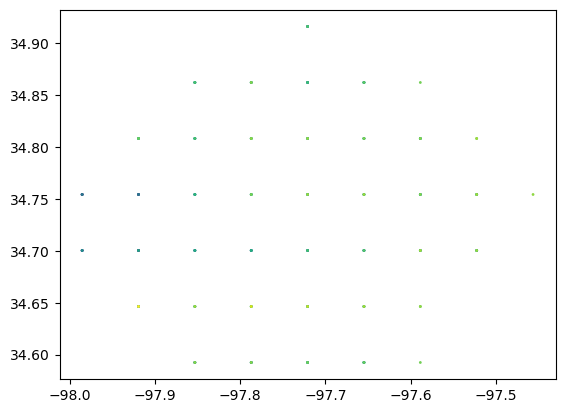

In [12]:
#P.scatter(lon[index_kind]/1000, lat[index_kind]/1000, c=value[index_kind], s=.5)
P.scatter(lon[index_kind], lat[index_kind], c=value[index_kind], s=1)
# P.xlim(0,140)
# P.ylim(0,140)

In [9]:
 kind, value, error, lat, lon, xob, yob, zob, tob, Hxf, Hxfbar, outlier = read_prior(analysis_time, file=prior_file, sort=True)

Prior obs file found, opening /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:00:00.nc 

Total number of obs in /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:00:00.nc file is 2049 



In [10]:
len(kind)

2049

In [11]:
ob_err      = error[index_kind].mean()
d           = dep[index_kind]
Hxftmp      = Hxf[index_kind,:]
Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
inno_var    = N.mean((d - d.mean())**2)
consi_ratio = (ob_err + Hxf_var) / inno_var

In [13]:
d

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan])

In [17]:
index_kind  = getIndexEqual(kind, 12)
Hxfbar[index_kind]

masked_array(data=[0., 0., 0., ..., 0., 0., 0.],
             mask=False,
       fill_value=1e+20)